# Empezamos con el proceso de reducción dimensional

In [1]:

from pathlib import Path
from datetime import datetime

RUTA_PROYECTO = Path(
    r"C:\Users\marco\Documentos\investigacion"
    r"\machine_learning_idalina\6_redes_neuronales"
)

RUTA_DATOS_RAW = RUTA_PROYECTO / "2_datos" / "1_raw"

RUTA_PROCESADOS = RUTA_PROYECTO / "2_datos" / "2_procesados"

RUTA_RESULTADOS = RUTA_PROYECTO / "3_resultados"

RUTA_DATOS_RAW.mkdir(parents=True, exist_ok=True)
RUTA_PROCESADOS.mkdir(parents=True, exist_ok=True)
RUTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

print("Proyecto:")
print(RUTA_PROYECTO)

print("\nDatos originales:")
print(RUTA_DATOS_RAW)

print("\nDatos procesados:")
print(RUTA_PROCESADOS)

print("\nResultados MLP:")
print(RUTA_RESULTADOS)


Proyecto:
C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales

Datos originales:
C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\1_raw

Datos procesados:
C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados

Resultados MLP:
C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\3_resultados


In [2]:
import pandas as pd  

RUTA_EXCEL = (
    RUTA_DATOS_RAW /
    "2_meteo_epi_2021-2026_1_rezagos.xlsx"
)

df = pd.read_excel(   RUTA_EXCEL,   parse_dates=["fecha"])

df = df.sort_values("fecha").reset_index(drop=True)

print("Filas:", len(df))
print("Columnas:", len(df.columns))

df.head()

Filas: 270
Columnas: 172


,fecha,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,...,casos_dengue_lag_3,casos_dengue_lag_4,casos_dengue_lag_5,casos_dengue_lag_6,casos_dengue_lag_7,casos_dengue_lag_8,casos_dengue_lag_9,casos_dengue_lag_10,casos_dengue_lag_11,casos_dengue_lag_12
0,2021-03-28,2021,13,31.554286,36.747143,26.918571,15.725714,55.717143,0.67,0,...,0,1,0,1,1,0,0,1,0,0
1,2021-04-04,2021,14,29.200000,33.907143,25.458571,16.550000,66.907143,5.02,2,...,0,0,1,0,1,1,0,0,1,0
2,2021-04-11,2021,15,28.248571,32.278571,25.132857,17.790000,75.144286,40.07,5,...,0,0,0,1,0,1,1,0,0,1
3,2021-04-18,2021,16,29.072857,34.704286,25.035714,17.598571,72.110000,22.25,1,...,1,0,0,0,1,0,1,1,0,0
4,2021-04-25,2021,17,29.080000,34.357143,25.041429,16.558571,67.494286,1.46,1,...,0,1,0,0,0,1,0,1,1,0


In [3]:
df.columns.to_numpy 

<bound method IndexOpsMixin.to_numpy of Index(['fecha', 'año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia',
       ...
       'casos_dengue_lag_3', 'casos_dengue_lag_4', 'casos_dengue_lag_5',
       'casos_dengue_lag_6', 'casos_dengue_lag_7', 'casos_dengue_lag_8',
       'casos_dengue_lag_9', 'casos_dengue_lag_10', 'casos_dengue_lag_11',
       'casos_dengue_lag_12'],
      dtype='str', length=172)>

In [4]:
df_columns = pd.DataFrame(df.columns.to_numpy(), columns=['columnas'])
df_columns 

,columnas
0,fecha
1,año
2,semana_epi
3,temp
4,temp_max
...,...
167,casos_dengue_lag_8
168,casos_dengue_lag_9
169,casos_dengue_lag_10
170,casos_dengue_lag_11


In [5]:
df_columns.to_excel(r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\1_raw\columnas_dataset_rezago.xlsx", index = False)

# Diferentes formas de reducción dimensional para una MLP

In [ ]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import os
from datetime import datetime


# ============================================================
# 0. CONFIGURACIÓN DE RUTAS
# ============================================================
RUTA_EXCEL = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\1_raw\2_meteo_epi_2021-2026_1_rezagos.xlsx"
RUTA_PROCESADOS = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados"

# Crear carpeta si no existe
os.makedirs(RUTA_PROCESADOS, exist_ok=True)

# Variables climáticas base (ya vienen con sus lags 1-12 en el Excel de entrada)
VARIABLES_BASE = [
    "temp", "temp_max", "temp_min", "hum_esp", "hum_rel",
    "prec", "dias_lluvia", "vel_vi", "vel_vi_max", "vel_vi_min",
    "soi", "sst",
]

# Columnas que no deben tratarse como features candidatas para la reducción
COLUMNAS_NO_FEATURE = ["fecha", "casos_dengue"]


# ============================================================
# 1. FUNCIONES DE CARGA Y PREPROCESAMIENTO
# ============================================================
def cargar_datos():
    df = pd.read_excel(RUTA_EXCEL, parse_dates=["fecha"])
    print(f"Datos reales cargados ({len(df)} filas, {df.shape[1]} columnas).")
    return df.sort_values("fecha").reset_index(drop=True)


def split_temporal(df, proporcion_train=0.8):
    n = len(df)
    corte = int(n * proporcion_train)
    return df.iloc[:corte].copy(), df.iloc[corte:].copy()


def limpiar_nan(df, method='ffill'):
    """
    Limpia valores NaN en el dataset
    method: 'ffill' (forward fill), 'bfill' (backward fill),
            'drop', 'zero', 'mean'
    """
    df_clean = df.copy()

    if method == 'ffill':
        df_clean = df_clean.ffill()
        df_clean = df_clean.fillna(0)
    elif method == 'bfill':
        df_clean = df_clean.bfill()
        df_clean = df_clean.fillna(0)
    elif method == 'drop':
        df_clean = df_clean.dropna()
    elif method == 'zero':
        df_clean = df_clean.fillna(0)
    elif method == 'mean':
        for col in df_clean.columns:
            if df_clean[col].dtype in ['float64', 'int64']:
                mean_val = df_clean[col].mean()
                df_clean[col] = df_clean[col].fillna(mean_val)

    df_clean = df_clean.fillna(0)
    return df_clean


def crear_features_avanzadas(df):
    """
    Crea features derivadas adicionales A PARTIR del dataset de 172 columnas
    ya provisto (que incluye fecha, año, semana_epi, las 12 variables
    climáticas base, casos_dengue y sus lags 1-12).

    IMPORTANTE: aquí NO se vuelven a calcular los lags de las variables
    base ni de casos_dengue, porque ya existen en el archivo de entrada.
    Solo se agregan agregaciones móviles, ratios, interacciones y
    estacionalidad.
    """
    df_adv = df.copy()

    # 1. Agregaciones móviles de casos (ventanas de 2, 4, 8 semanas)
    for window in [2, 4, 8]:
        df_adv[f'casos_media_{window}w'] = df_adv['casos_dengue'].rolling(window).mean()
        df_adv[f'casos_max_{window}w'] = df_adv['casos_dengue'].rolling(window).max()
        df_adv[f'casos_tendencia_{window}w'] = df_adv['casos_dengue'].diff(window)

    # 2. Features climáticas agregadas (ventanas de 4, 8, 12 semanas)
    for var in ['temp', 'prec', 'hum_rel']:
        for window in [4, 8, 12]:
            df_adv[f'{var}_media_{window}w'] = df_adv[var].rolling(window).mean()
            df_adv[f'{var}_max_{window}w'] = df_adv[var].rolling(window).max()

    # 3. Razones y ratios climáticos
    df_adv['prec_temp_ratio'] = df_adv['prec'] / (df_adv['temp'] + 0.1)
    df_adv['hum_temp_interaction'] = df_adv['hum_rel'] * df_adv['temp']
    df_adv['temp_range'] = df_adv['temp_max'] - df_adv['temp_min']

    # 4. Indicadores de estacionalidad adicionales
    #    (año y semana_epi ya vienen en el dataset original; se agrega
    #    además el mes calendario y la semana ISO del año)
    df_adv['mes'] = df_adv['fecha'].dt.month
    df_adv['semana_del_ano'] = df_adv['fecha'].dt.isocalendar().week.astype(int)

    return df_adv


# ============================================================
# 2. FUNCIONES DE REDUCCIÓN DIMENSIONAL
# ============================================================
def seleccionar_por_importancia(df, features, threshold=0.01):
    """
    Selecciona features con importancia > threshold usando Random Forest
    """
    X = df[features].values
    y = df['casos_dengue'].values

    imp = SimpleImputer(strategy='median')
    X_clean = imp.fit_transform(X)

    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf.fit(X_clean, y)

    importancias = pd.DataFrame({
        'feature': features,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)

    selected = importancias[importancias['importance'] > threshold]['feature'].tolist()

    print(f"  Importancia > {threshold}: seleccionadas {len(selected)} features")
    if len(selected) > 0:
        print(f"  Top 5: {selected[:5]}")
    return selected, importancias


def seleccionar_rfe(df, features, n_features=15):
    """
    Selección recursiva de features con Random Forest
    """
    X = df[features].values
    y = df['casos_dengue'].values

    imp = SimpleImputer(strategy='median')
    X_clean = imp.fit_transform(X)

    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    selector = RFE(rf, n_features_to_select=n_features, step=1)
    selector.fit(X_clean, y)

    selected = [features[i] for i in range(len(features)) if selector.support_[i]]
    print(f"  RFE seleccionó {len(selected)} features")
    return selected


def seleccionar_lags_optimos(df):
    """
    Encuentra los lags más importantes de casos_dengue (ya presentes en el
    dataset de entrada como casos_dengue_lag_1 ... casos_dengue_lag_12)
    """
    lags = [f'casos_dengue_lag_{lag}' for lag in range(1, 13)
            if f'casos_dengue_lag_{lag}' in df.columns]

    if len(lags) == 0:
        print("  No se encontraron lags de casos_dengue en el dataset de entrada")
        return []

    X = df[lags].values
    y = df['casos_dengue'].values

    imp = SimpleImputer(strategy='median')
    X_clean = imp.fit_transform(X)

    correlaciones = []
    for i, col in enumerate(lags):
        corr = np.corrcoef(X_clean[:, i], y)[0, 1]
        if not np.isnan(corr):
            correlaciones.append((col, abs(corr)))

    if len(correlaciones) == 0:
        return []

    correlaciones.sort(key=lambda x: x[1], reverse=True)
    selected = [col for col, corr in correlaciones if corr > 0.3]
    print(f"  Lags seleccionados: {len(selected)}")
    return selected


def aplicar_pca(df, features, n_components=10):
    """
    Aplica PCA para reducir dimensionalidad
    Retorna: df_pca, pca_cols, pca_model, explained_variance
    """
    X = df[features].values

    imp = SimpleImputer(strategy='median')
    X_clean = imp.fit_transform(X)

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_clean)

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    explained_variance = pca.explained_variance_ratio_
    print(f"  PCA: {n_components} componentes explican {explained_variance.sum():.2%}")

    pca_cols = [f'PC_{i+1}' for i in range(n_components)]
    df_pca = pd.DataFrame(X_pca, columns=pca_cols)
    df_pca['fecha'] = df['fecha'].values
    df_pca['casos_dengue'] = df['casos_dengue'].values

    return df_pca, pca_cols, pca, explained_variance


# ============================================================
# 3. FUNCIÓN PARA GUARDAR DATASETS REDUCIDOS
# ============================================================
def guardar_dataset_reducido(df, features_seleccionadas, metodo, total_features_originales, descripcion=""):
    """
    Guarda el dataset reducido y la lista de atributos seleccionados
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    columnas_guardar = ['fecha', 'casos_dengue'] + features_seleccionadas
    df_reducido = df[columnas_guardar].copy()

    nombre_base = f"dengue_reducido_{metodo}"
    if descripcion:
        nombre_base += f"_{descripcion}"
    nombre_base += f"_{timestamp}"

    archivo_excel = os.path.join(RUTA_PROCESADOS, f"{nombre_base}.xlsx")
    df_reducido.to_excel(archivo_excel, index=False)
    print(f"  ✅ Dataset reducido guardado: {archivo_excel}")

    archivo_atributos = os.path.join(RUTA_PROCESADOS, f"{nombre_base}_atributos.xlsx")
    df_atributos = pd.DataFrame({
        'feature': features_seleccionadas,
        'orden': range(1, len(features_seleccionadas) + 1)
    })
    df_atributos.to_excel(archivo_atributos, index=False)
    print(f"  ✅ Lista de atributos guardada: {archivo_atributos}")

    # Reducción calculada contra el total de features CANDIDATAS antes de
    # reducir (antes este cálculo comparaba n contra n y siempre daba 0%)
    reduccion_pct = (1 - len(features_seleccionadas) / total_features_originales) * 100

    archivo_resumen = os.path.join(RUTA_PROCESADOS, f"{nombre_base}_resumen.xlsx")
    df_resumen = pd.DataFrame({
        'metadato': ['Método', 'Fecha', 'Total features candidatas', 'Features seleccionadas',
                     'Reducción (%)', 'Descripción'],
        'valor': [metodo, timestamp, total_features_originales,
                  len(features_seleccionadas),
                  f"{reduccion_pct:.1f}%",
                  descripcion]
    })
    df_resumen.to_excel(archivo_resumen, index=False)
    print(f" Resumen guardado: {archivo_resumen}")

    return archivo_excel, archivo_atributos, archivo_resumen


# ============================================================
# 4. FUNCIÓN PRINCIPAL DE REDUCCIÓN DIMENSIONAL
# ============================================================
def reducir_dimensionalidad_y_guardar(df_completo, metodo='importancia', **kwargs):
    """
    Aplica reducción dimensional y guarda los resultados

    Parámetros:
    - metodo: 'importancia', 'rfe', 'lags', 'pca', 'combinado'
    - kwargs: parámetros específicos del método
    """
    print(f"\n{'='*70}")
    print(f"REDUCCIÓN DIMENSIONAL - MÉTODO: {metodo.upper()}")
    print(f"{'='*70}")

    # Crear features avanzadas SOBRE el dataset de 172 columnas ya provisto
    print("\n1️⃣ Creando features avanzadas (agregaciones, ratios, estacionalidad)...")
    df_adv = crear_features_avanzadas(df_completo)
    df_adv = limpiar_nan(df_adv, method='ffill')

    assert df_adv.isna().sum().sum() == 0, "Aún hay NaN en los datos!"

    cols = [col for col in df_adv.columns if col not in COLUMNAS_NO_FEATURE]
    print(f"  Features candidatas totales (172 originales + derivadas): {len(cols)}")

    features_seleccionadas = []
    descripcion = ""

    if metodo == 'importancia':
        threshold = kwargs.get('threshold', 0.005)
        features_seleccionadas, importancias = seleccionar_por_importancia(
            df_adv, cols, threshold=threshold
        )
        descripcion = f"threshold_{threshold}"

        archivo_importancias = os.path.join(RUTA_PROCESADOS,
            f"importancias_features_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx")
        importancias.to_excel(archivo_importancias, index=False)
        print(f"  ✅ Importancias guardadas: {archivo_importancias}")

    elif metodo == 'rfe':
        n_features = kwargs.get('n_features', 20)
        features_seleccionadas = seleccionar_rfe(df_adv, cols, n_features=n_features)
        descripcion = f"n_{n_features}"

    elif metodo == 'lags':
        features_seleccionadas = seleccionar_lags_optimos(df_adv)
        descripcion = "lags_optimos"

    elif metodo == 'pca':
        n_components = kwargs.get('n_components', 10)
        df_pca, pca_cols, pca_model, explained_variance = aplicar_pca(
            df_adv, cols, n_components=n_components
        )
        descripcion = f"pca_{n_components}"
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

        archivo_pca = os.path.join(RUTA_PROCESADOS, f"dengue_pca_{n_components}comp_{timestamp}.xlsx")
        df_pca.to_excel(archivo_pca, index=False)
        print(f"  ✅ Dataset PCA guardado: {archivo_pca}")

        archivo_comp = os.path.join(RUTA_PROCESADOS, f"pca_componentes_{timestamp}.xlsx")
        pd.DataFrame({
            'componente': pca_cols,
            'varianza_explicada': explained_variance,
            'varianza_acumulada': np.cumsum(explained_variance)
        }).to_excel(archivo_comp, index=False)
        print(f"  ✅ Componentes PCA guardados: {archivo_comp}")

        archivo_loadings = os.path.join(RUTA_PROCESADOS, f"pca_loadings_{timestamp}.xlsx")
        df_loadings = pd.DataFrame(
            pca_model.components_.T,
            columns=pca_cols,
            index=cols
        )
        df_loadings.to_excel(archivo_loadings)
        print(f"  ✅ PCA loadings guardados: {archivo_loadings}")

        # Se devuelven también las rutas de archivos para que la tabla
        # comparativa final quede completa (antes se perdían)
        archivos_pca = (archivo_pca, archivo_comp, archivo_loadings)
        return df_pca, pca_cols, archivos_pca

    elif metodo == 'combinado':
        print("\n  Paso 1: Selección por importancia...")
        temp_selected, _ = seleccionar_por_importancia(df_adv, cols, threshold=0.005)

        print("\n  Paso 2: RFE sobre features seleccionadas...")
        n_final = kwargs.get('n_final', 15)
        features_seleccionadas = seleccionar_rfe(df_adv, temp_selected, n_features=n_final)
        descripcion = f"combinado_n{n_final}"

    if len(features_seleccionadas) == 0:
        print("  ⚠️ No se seleccionaron features, usando todas...")
        features_seleccionadas = cols
        descripcion = "todas_las_features"

    print(f"\n2️⃣ Guardando datasets reducidos...")
    archivos = guardar_dataset_reducido(
        df_adv,
        features_seleccionadas,
        metodo,
        total_features_originales=len(cols),
        descripcion=descripcion
    )

    print(f"\n{'='*70}")
    print("RESUMEN DE REDUCCIÓN DIMENSIONAL")
    print(f"{'='*70}")
    print(f"  Método: {metodo}")
    print(f"  Features candidatas: {len(cols)}")
    print(f"  Features seleccionadas: {len(features_seleccionadas)}")
    print(f"  Reducción: {(1 - len(features_seleccionadas)/len(cols))*100:.1f}%")
    print(f"  Archivos guardados en: {RUTA_PROCESADOS}")

    return df_adv, features_seleccionadas, archivos


# ============================================================
# 5. EJECUCIÓN PRINCIPAL
# ============================================================
if __name__ == "__main__":

    print("="*70)
    print("REDUCCIÓN DIMENSIONAL PARA DATOS DE DENGUE")
    print("="*70)

    print("\n Cargando datos (dataset de 172 features con lags ya calculados)...")
    df = cargar_datos()

    resultados = {}

    # Método 1: Importancia (threshold ajustable)
    print("\n" + "="*70)
    print("MÉTODO 1: SELECCIÓN POR IMPORTANCIA")
    print("="*70)
    df_reducido, features_imp, archivos_imp = reducir_dimensionalidad_y_guardar(
        df, metodo='importancia', threshold=0.005
    )
    resultados['importancia'] = {
        'features': features_imp, 'n_features': len(features_imp),
        'archivos': archivos_imp
    }

    # Método 2: RFE
    print("\n" + "="*70)
    print("MÉTODO 2: RECURSIVE FEATURE ELIMINATION (RFE)")
    print("="*70)
    df_reducido, features_rfe, archivos_rfe = reducir_dimensionalidad_y_guardar(
        df, metodo='rfe', n_features=20
    )
    resultados['rfe'] = {
        'features': features_rfe, 'n_features': len(features_rfe),
        'archivos': archivos_rfe
    }

    # Método 3: Lags óptimos
    print("\n" + "="*70)
    print("MÉTODO 3: LAGS ÓPTIMOS")
    print("="*70)
    df_reducido, features_lags, archivos_lags = reducir_dimensionalidad_y_guardar(
        df, metodo='lags'
    )
    resultados['lags'] = {
        'features': features_lags, 'n_features': len(features_lags),
        'archivos': archivos_lags
    }

    # Método 4: PCA
    print("\n" + "="*70)
    print("MÉTODO 4: PCA")
    print("="*70)
    df_pca, componentes_pca, archivos_pca = reducir_dimensionalidad_y_guardar(
        df, metodo='pca', n_components=10
    )
    resultados['pca'] = {
        'features': componentes_pca, 'n_features': len(componentes_pca),
        'archivos': archivos_pca
    }

    # Método 5: Combinado (Importancia + RFE)
    print("\n" + "="*70)
    print("MÉTODO 5: COMBINADO (Importancia + RFE)")
    print("="*70)
    df_reducido, features_comb, archivos_comb = reducir_dimensionalidad_y_guardar(
        df, metodo='combinado', n_final=15
    )
    resultados['combinado'] = {
        'features': features_comb, 'n_features': len(features_comb),
        'archivos': archivos_comb
    }

    # ============================================================
    # 6. RESUMEN FINAL COMPARATIVO
    # ============================================================
    print("\n" + "="*70)
    print("RESUMEN COMPARATIVO DE TODOS LOS MÉTODOS")
    print("="*70)

    # Total de features candidatas (172 originales + derivadas), recalculado
    # una vez para usar como base común de comparación
    df_adv_ref = crear_features_avanzadas(df)
    total_candidatas = len([c for c in df_adv_ref.columns if c not in COLUMNAS_NO_FEATURE])

    tabla_comparativa = pd.DataFrame({
        'Método': list(resultados.keys()),
        'Features seleccionadas': [r['n_features'] for r in resultados.values()],
        'Reducción (%)': [f"{(1 - r['n_features']/total_candidatas)*100:.1f}%"
                          for r in resultados.values()]
    })
    print(tabla_comparativa.to_string(index=False))

    archivo_comparativa = os.path.join(RUTA_PROCESADOS,
        f"comparativa_metodos_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx")
    tabla_comparativa.to_excel(archivo_comparativa, index=False)
    print(f"\n Tabla comparativa guardada: {archivo_comparativa}")

    archivo_todos_atributos = os.path.join(RUTA_PROCESADOS,
        f"todos_atributos_seleccionados_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx")

    with pd.ExcelWriter(archivo_todos_atributos) as writer:
        for metodo, info in resultados.items():
            df_atributos = pd.DataFrame({
                'feature': info['features'],
                'orden': range(1, len(info['features']) + 1)
            })
            df_atributos.to_excel(writer, sheet_name=metodo, index=False)
    print(f"Todos los atributos guardados en: {archivo_todos_atributos}")

    print("\n" + "="*70)
    print("🎉 PROCESO DE REDUCCIÓN DIMENSIONAL COMPLETADO")
    print("="*70)
    print(f" Todos los archivos guardados en: {RUTA_PROCESADOS}")
    print("\nArchivos generados:")
    print("  - dengue_reducido_[metodo]_[timestamp].xlsx (datos reducidos)")
    print("  - dengue_reducido_[metodo]_[timestamp]_atributos.xlsx (lista de atributos)")
    print("  - dengue_reducido_[metodo]_[timestamp]_resumen.xlsx (resumen del método)")
    print("  - comparativa_metodos_[timestamp].xlsx (comparación entre métodos)")
    print("  - todos_atributos_seleccionados_[timestamp].xlsx (todos los atributos)")
    print("  - importancias_features_[timestamp].xlsx (importancias completas)")
    print("  - pca_componentes_[timestamp].xlsx (componentes PCA)")
    print("  - pca_loadings_[timestamp].xlsx (matriz de loadings PCA)")


REDUCCIÓN DIMENSIONAL PARA DATOS DE DENGUE

 Cargando datos (dataset de 172 features con lags ya calculados)...
Datos reales cargados (270 filas, 172 columnas).

MÉTODO 1: SELECCIÓN POR IMPORTANCIA

REDUCCIÓN DIMENSIONAL - MÉTODO: IMPORTANCIA

1️⃣ Creando features avanzadas (agregaciones, ratios, estacionalidad)...
  Features candidatas totales (172 originales + derivadas): 202
  Importancia > 0.005: seleccionadas 3 features
  Top 5: ['casos_media_2w', 'casos_max_2w', 'casos_media_4w']
  ✅ Importancias guardadas: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados\importancias_features_20260821_112740.xlsx

2️⃣ Guardando datasets reducidos...
  ✅ Dataset reducido guardado: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados\dengue_reducido_importancia_threshold_0.005_20260821_112740.xlsx
  ✅ Lista de atributos guardada: C:\Users\marco\Documentos\investigacion\machine_learning_idali

c:\Users\marco\Documentos\investigacion\machine_learning_idalina\.venv\Lib\site-packages\sklearn\feature_selection\_rfe.py:300: UserWarning: Found n_features_to_select=15 > n_features=3. There will be no feature selection and all features will be kept.
  warnings.warn(


  ✅ Dataset reducido guardado: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados\dengue_reducido_combinado_combinado_n15_20260821_113019.xlsx
  ✅ Lista de atributos guardada: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados\dengue_reducido_combinado_combinado_n15_20260821_113019_atributos.xlsx
  ✅ Resumen guardado: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados\dengue_reducido_combinado_combinado_n15_20260821_113019_resumen.xlsx

RESUMEN DE REDUCCIÓN DIMENSIONAL
  Método: combinado
  Features candidatas: 202
  Features seleccionadas: 3
  Reducción: 98.5%
  Archivos guardados en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados

RESUMEN COMPARATIVO DE TODOS LOS MÉTODOS
     Método  Features seleccionadas Reducción (%)
importancia                       3         98.5

# Ahora si el modelo de red neuronal MLP para el dataset reducido con la metodología RLF de 20 atributos 

ENTRENAMIENTO MLP PARA MAE < 4
ARCHIVO: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados\dengue_reducido_rfe_n_20_20260810_164451.xlsx

 Cargando datos...

📂 Cargando datos: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados\dengue_reducido_rfe_n_20_20260810_164451.xlsx
   Filas: 270
   Columnas: 22
   Columnas disponibles: ['fecha', 'casos_dengue', 'semana_epi', 'temp_lag_9', 'temp_lag_11', 'temp_min_lag_1', 'temp_min_lag_2', 'temp_min_lag_3', 'hum_rel_lag_1', 'prec_lag_4', 'prec_lag_6', 'vel_vi_max_lag_1', 'vel_vi_max_lag_2', 'vel_vi_min_lag_7', 'casos_dengue_lag_1', 'casos_media_2w', 'casos_max_2w', 'casos_tendencia_2w', 'casos_media_4w', 'casos_tendencia_4w', 'casos_tendencia_8w', 'hum_temp_interaction']
Se usarán las 20 features especificadas

 Preparando datos...

📊 División de datos:
   Entrenamiento: 216 filas
   Prueba: 54 filas
   Features: 20
   Target: casos_dengue 

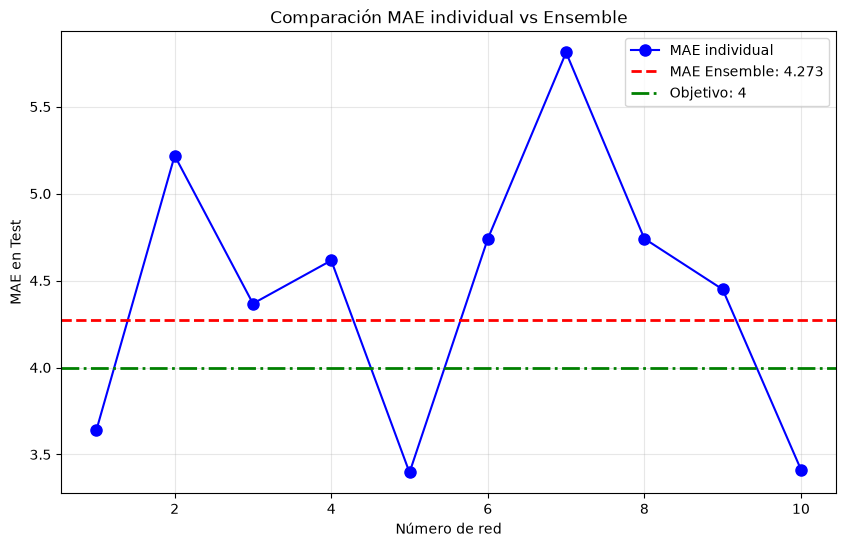


 Generando gráficas...

 Gráfica guardada: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\3_resultados\resultados_mlp_20260821_170722.png


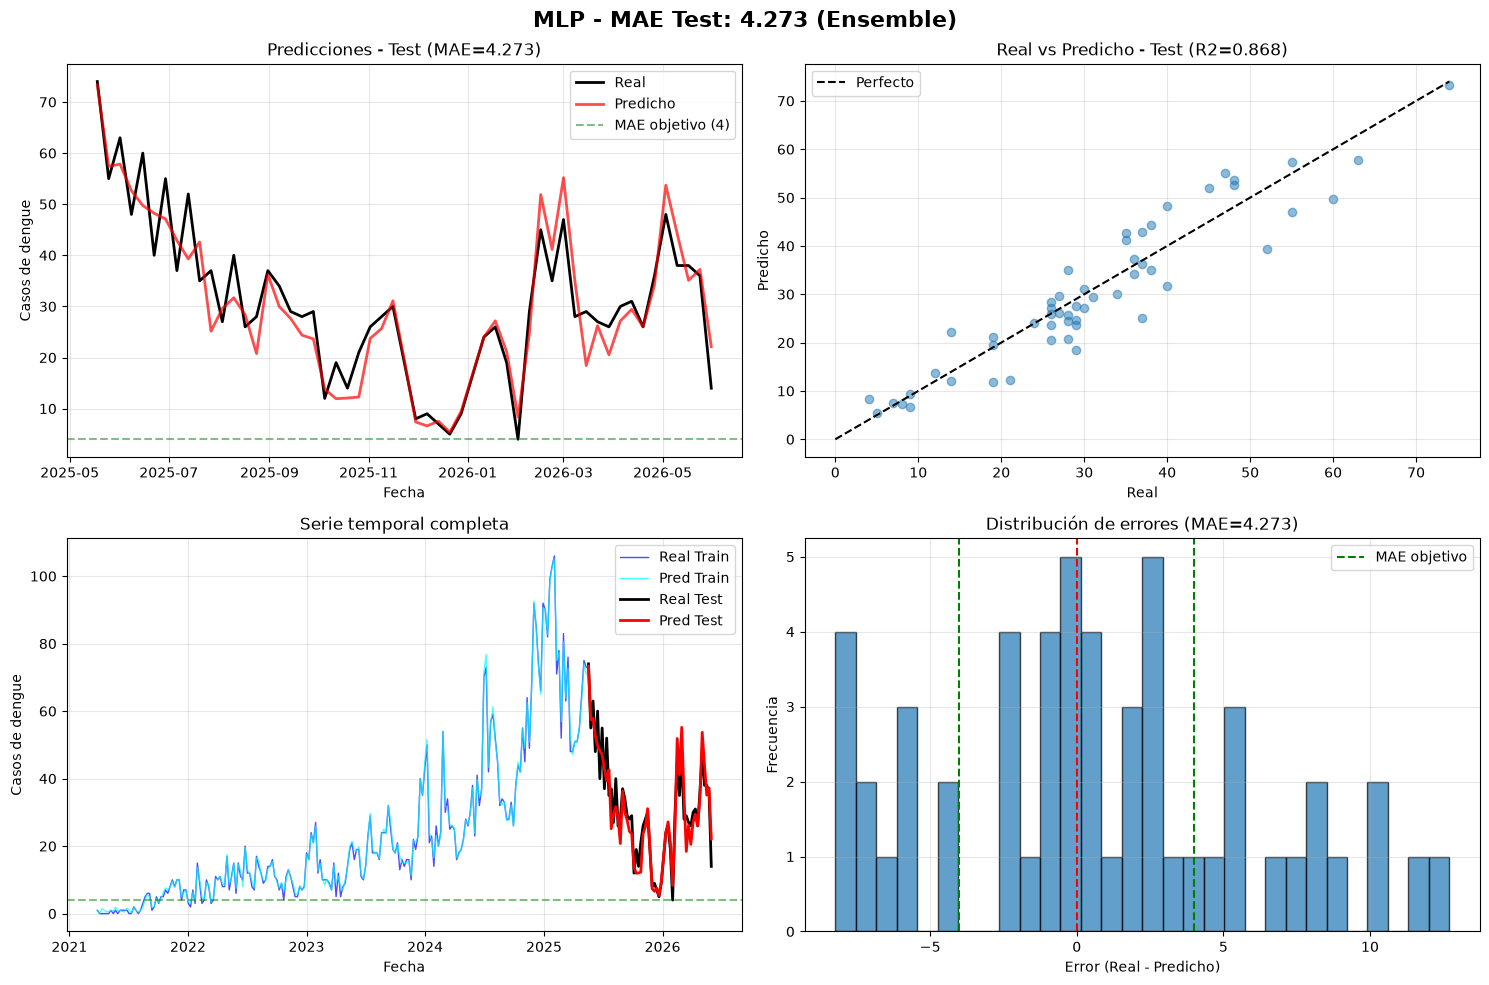


 Guardando resultados...
 Predicciones guardadas: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\3_resultados\predicciones_20260821_170723.xlsx
 Métricas guardadas: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\3_resultados\metricas_20260821_170723.xlsx
 Features usadas guardadas: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\3_resultados\features_usadas_20260821_170723.xlsx

RESUMEN FINAL
  MAE Train: 0.889
  MAE Test:  4.273
  R2 Train:  0.997
  R2 Test:   0.868
  Features usadas: 20

 MAE = 4.273 > 4
   Diferencia: 0.273

 Recomendaciones para mejorar:
   1. Aumentar n_models en ensemble (15-20)
   2. Probar arquitectura más profunda: (256, 128, 64, 32)
   3. Aumentar max_iter a 5000
   4. Verificar la calidad de las 20 features seleccionadas por RFE

 Resultados guardados en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\3_resultado

In [16]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import os
from datetime import datetime
import seaborn as sns

# ============================================================
# 0. CONFIGURACIÓN DE RUTAS
# ============================================================
RUTA_PROCESADOS = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados"

RUTA_RESULTADOS = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\3_resultados"

# Archivo específico que se debe usar (ya NO se busca automáticamente el más reciente)
ARCHIVO_DATOS = os.path.join(RUTA_PROCESADOS, "dengue_reducido_rfe_n_20_20260810_164451.xlsx")

# Variables predictoras fijas que se deben usar para entrenar el modelo
FEATURES_FIJAS = [
    'semana_epi',
    'temp_lag_9',
    'temp_lag_11',
    'temp_min_lag_1',
    'temp_min_lag_2',
    'temp_min_lag_3',
    'hum_rel_lag_1',
    'prec_lag_4',
    'prec_lag_6',
    'vel_vi_max_lag_1',
    'vel_vi_max_lag_2',
    'vel_vi_min_lag_7',
    'casos_dengue_lag_1',
    'casos_media_2w',
    'casos_max_2w',
    'casos_tendencia_2w',
    'casos_media_4w',
    'casos_tendencia_4w',
    'casos_tendencia_8w',
    'hum_temp_interaction'
]

TARGET = 'casos_dengue'

# Crear carpeta de resultados
os.makedirs(RUTA_RESULTADOS, exist_ok=True)

# ============================================================
# 1. CARGAR DATOS DEL ARCHIVO ESPECÍFICO
# ============================================================
def cargar_datos_reducidos():
    """
    Carga el dataset ubicado en ARCHIVO_DATOS (ruta fija, sin búsqueda automática)
    """
    if not os.path.exists(ARCHIVO_DATOS):
        raise FileNotFoundError(f"No se encontró el archivo especificado: {ARCHIVO_DATOS}")

    print(f"\n📂 Cargando datos: {ARCHIVO_DATOS}")
    df = pd.read_excel(ARCHIVO_DATOS)

    print(f"   Filas: {len(df)}")
    print(f"   Columnas: {len(df.columns)}")
    print(f"   Columnas disponibles: {df.columns.tolist()}")

    # Identificar columna de fecha
    columna_fecha = None
    for col in df.columns:
        if 'fecha' in col.lower() or 'date' in col.lower():
            columna_fecha = col
            break

    if columna_fecha is None:
        print("   ⚠️ No se encontró columna de fecha. Creando índice temporal...")
        df['fecha'] = pd.date_range(start='2021-03-28', periods=len(df), freq='W')
    else:
        try:
            df[columna_fecha] = pd.to_datetime(df[columna_fecha])
            if columna_fecha != 'fecha':
                df = df.rename(columns={columna_fecha: 'fecha'})
        except Exception:
            print(f"No se pudo convertir '{columna_fecha}' a datetime")
            df['fecha'] = pd.date_range(start='2021-03-28', periods=len(df), freq='W')

    # Verificar que la columna objetivo exista
    if TARGET not in df.columns:
        raise ValueError(f"No se encontró la columna objetivo '{TARGET}' en el archivo cargado")

    # Verificar que todas las features fijas existan en el dataframe
    faltantes = [f for f in FEATURES_FIJAS if f not in df.columns]
    if faltantes:
        raise ValueError(f"Las siguientes features no están en el archivo cargado: {faltantes}")

    print(f"Se usarán las {len(FEATURES_FIJAS)} features especificadas")

    # Ordenar por fecha si existe
    if 'fecha' in df.columns:
        df = df.sort_values('fecha').reset_index(drop=True)

    # Dataframe de atributos (referencia, coherente con el resto del pipeline)
    df_atributos = pd.DataFrame({
        'feature': FEATURES_FIJAS,
        'orden': range(1, len(FEATURES_FIJAS) + 1)
    })

    return df, df_atributos

# ============================================================
# 2. PREPROCESAMIENTO DE DATOS
# ============================================================
def preparar_datos(df, train_ratio=0.8):
    """
    Prepara los datos para entrenamiento y prueba usando únicamente FEATURES_FIJAS
    """
    features = FEATURES_FIJAS

    X = df[features].values
    y = df[TARGET].values

    # Split temporal (respetando orden)
    n = len(df)
    corte = int(n * train_ratio)

    X_train, X_test = X[:corte], X[corte:]
    y_train, y_test = y[:corte], y[corte:]
    fechas_train = df['fecha'].iloc[:corte] if 'fecha' in df.columns else pd.Series(range(corte))
    fechas_test = df['fecha'].iloc[corte:] if 'fecha' in df.columns else pd.Series(range(corte, n))

    print(f"\n📊 División de datos:")
    print(f"   Entrenamiento: {len(X_train)} filas")
    print(f"   Prueba: {len(X_test)} filas")
    print(f"   Features: {len(features)}")
    print(f"   Target: {TARGET} (media={y.mean():.2f}, std={y.std():.2f})")

    return X_train, X_test, y_train, y_test, fechas_train, fechas_test, features

# ============================================================
# 3. FUNCIÓN DE ENTRENAMIENTO MLP MEJORADA
# ============================================================
def entrenar_mlp_optimizada(X_train, y_train, X_test, y_test,
                           hidden_layer_sizes=(128, 64, 32, 16),
                           alpha=0.001, learning_rate_init=0.005,
                           max_iter=3000, semilla=42):
    """
    Entrena una MLP con configuración optimizada para MAE < 4
    """
    scaler_X = RobustScaler(quantile_range=(5, 95))
    X_train_s = scaler_X.fit_transform(X_train)
    X_test_s = scaler_X.transform(X_test)

    scaler_y = RobustScaler()
    y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

    modelo = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation='relu',
        solver='adam',
        alpha=alpha,
        batch_size=32,
        max_iter=max_iter,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=25,
        random_state=semilla,
        learning_rate='adaptive',
        learning_rate_init=learning_rate_init,
        tol=1e-5,
        verbose=False
    )

    print(f"\n🤖 Entrenando MLP...")
    print(f"   Arquitectura: {hidden_layer_sizes}")
    print(f"   Regularización alpha: {alpha}")
    print(f"   Learning rate: {learning_rate_init}")

    modelo.fit(X_train_s, y_train_s)

    y_train_pred_s = modelo.predict(X_train_s)
    y_test_pred_s = modelo.predict(X_test_s)

    y_train_pred = scaler_y.inverse_transform(y_train_pred_s.reshape(-1, 1)).ravel()
    y_test_pred = scaler_y.inverse_transform(y_test_pred_s.reshape(-1, 1)).ravel()

    y_train_pred = np.maximum(y_train_pred, 0)
    y_test_pred = np.maximum(y_test_pred, 0)

    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    print(f"\n📊 Resultados:")
    print(f"   MAE Train: {mae_train:.3f}")
    print(f"   MAE Test:  {mae_test:.3f}")
    print(f"   R2 Train:  {r2_train:.3f}")
    print(f"   R2 Test:   {r2_test:.3f}")
    print(f"   RMSE Train: {rmse_train:.3f}")
    print(f"   RMSE Test:  {rmse_test:.3f}")

    return modelo, scaler_X, scaler_y, {
        'mae_train': mae_train,
        'mae_test': mae_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test,
        'r2_train': r2_train,
        'r2_test': r2_test
    }, y_train_pred, y_test_pred

# ============================================================
# 4. ENSEMBLE DE REDES PARA MEJORAR MAE
# ============================================================
def ensemble_mlp(X_train, y_train, X_test, y_test,
                n_models=10, hidden_layer_sizes=(128, 64, 32, 16),
                alpha=0.001, learning_rate_init=0.005):
    """
    Ensemble de redes neuronales para reducir varianza
    """
    print(f"\n{'='*70}")
    print("ENSEMBLE DE REDES NEURONALES")
    print(f"{'='*70}")
    print(f"Entrenando {n_models} redes...")

    predictions_train = []
    predictions_test = []
    maes_test = []
    modelos = []

    for seed in range(n_models):
        print(f"\n  Red {seed+1}/{n_models}...")

        modelo, _, _, metrics, y_train_pred, y_test_pred = entrenar_mlp_optimizada(
            X_train, y_train, X_test, y_test,
            hidden_layer_sizes=hidden_layer_sizes,
            alpha=alpha,
            learning_rate_init=learning_rate_init,
            semilla=seed
        )

        predictions_train.append(y_train_pred)
        predictions_test.append(y_test_pred)
        maes_test.append(metrics['mae_test'])
        modelos.append(modelo)

    y_train_ensemble = np.median(predictions_train, axis=0)
    y_test_ensemble = np.median(predictions_test, axis=0)

    mae_train_ens = mean_absolute_error(y_train, y_train_ensemble)
    mae_test_ens = mean_absolute_error(y_test, y_test_ensemble)
    rmse_train_ens = np.sqrt(mean_squared_error(y_train, y_train_ensemble))
    rmse_test_ens = np.sqrt(mean_squared_error(y_test, y_test_ensemble))
    r2_train_ens = r2_score(y_train, y_train_ensemble)
    r2_test_ens = r2_score(y_test, y_test_ensemble)

    print(f"\n{'='*70}")
    print("RESULTADOS DEL ENSEMBLE")
    print(f"{'='*70}")
    print(f"  MAE Test promedio individual: {np.mean(maes_test):.3f} ± {np.std(maes_test):.3f}")
    print(f"  MAE Test Ensemble (mediana): {mae_test_ens:.3f}")
    print(f"  MAE Train Ensemble: {mae_train_ens:.3f}")
    print(f"  RMSE Train Ensemble: {rmse_train_ens:.3f}")
    print(f"  RMSE Test Ensemble: {rmse_test_ens:.3f}")
    print(f"  R2 Train Ensemble: {r2_train_ens:.3f}")
    print(f"  R2 Test Ensemble: {r2_test_ens:.3f}")

    ensemble_metrics = {
        'mae_train': mae_train_ens,
        'mae_test': mae_test_ens,
        'rmse_train': rmse_train_ens,
        'rmse_test': rmse_test_ens,
        'r2_train': r2_train_ens,
        'r2_test': r2_test_ens,
        'maes_individuales': maes_test,
        'mean_mae': np.mean(maes_test),
        'std_mae': np.std(maes_test)
    }

    return y_train_ensemble, y_test_ensemble, ensemble_metrics, modelos

# ============================================================
# 5. GRÁFICAS Y VISUALIZACIÓN
# ============================================================
def graficar_resultados(fechas_train, y_train, y_train_pred,
                        fechas_test, y_test, y_test_pred,
                        metrics, titulo="Resultados MLP"):
    """
    Genera gráficas de resultados
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    ax1 = axes[0, 0]
    ax1.plot(fechas_test, y_test, label='Real', linewidth=2, color='black')
    ax1.plot(fechas_test, y_test_pred, label='Predicho', linewidth=2, color='red', alpha=0.7)
    ax1.axhline(y=4, color='green', linestyle='--', alpha=0.5, label='MAE objetivo (4)')
    ax1.set_title(f'Predicciones - Test (MAE={metrics["mae_test"]:.3f})')
    ax1.set_xlabel('Fecha' if isinstance(fechas_test.iloc[0], pd.Timestamp) else 'Índice')
    ax1.set_ylabel('Casos de dengue')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2 = axes[0, 1]
    ax2.scatter(y_test, y_test_pred, alpha=0.5)
    max_val = max(y_test.max(), y_test_pred.max())
    ax2.plot([0, max_val], [0, max_val], 'k--', label='Perfecto')
    ax2.set_title(f'Real vs Predicho - Test (R2={metrics["r2_test"]:.3f})')
    ax2.set_xlabel('Real')
    ax2.set_ylabel('Predicho')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    ax3.plot(fechas_train, y_train, label='Real Train', linewidth=1, color='blue', alpha=0.7)
    ax3.plot(fechas_train, y_train_pred, label='Pred Train', linewidth=1, color='cyan', alpha=0.7)
    ax3.plot(fechas_test, y_test, label='Real Test', linewidth=2, color='black')
    ax3.plot(fechas_test, y_test_pred, label='Pred Test', linewidth=2, color='red')
    ax3.axhline(y=4, color='green', linestyle='--', alpha=0.5)
    ax3.set_title('Serie temporal completa')
    ax3.set_xlabel('Fecha' if isinstance(fechas_test.iloc[0], pd.Timestamp) else 'Índice')
    ax3.set_ylabel('Casos de dengue')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 1]
    errores = y_test - y_test_pred
    ax4.hist(errores, bins=30, edgecolor='black', alpha=0.7)
    ax4.axvline(x=0, color='red', linestyle='--')
    ax4.axvline(x=4, color='green', linestyle='--', label='MAE objetivo')
    ax4.axvline(x=-4, color='green', linestyle='--')
    ax4.set_title(f'Distribución de errores (MAE={metrics["mae_test"]:.3f})')
    ax4.set_xlabel('Error (Real - Predicho)')
    ax4.set_ylabel('Frecuencia')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle(titulo, fontsize=16, fontweight='bold')
    plt.tight_layout()

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    archivo_fig = os.path.join(RUTA_RESULTADOS, f'resultados_mlp_{timestamp}.png')
    plt.savefig(archivo_fig, dpi=150, bbox_inches='tight')
    print(f"\n Gráfica guardada: {archivo_fig}")

    plt.show()
    return archivo_fig

def graficar_comparacion_mae(maes_individuales, mae_ensemble, objetivo=4):
    """
    Gráfica comparativa de MAE individual vs ensemble
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(range(1, len(maes_individuales)+1), maes_individuales,
            'o-', label='MAE individual', color='blue', markersize=8)

    ax.axhline(y=mae_ensemble, color='red', linestyle='--',
               linewidth=2, label=f'MAE Ensemble: {mae_ensemble:.3f}')

    ax.axhline(y=objetivo, color='green', linestyle='-.',
               linewidth=2, label=f'Objetivo: {objetivo}')

    ax.set_xlabel('Número de red')
    ax.set_ylabel('MAE en Test')
    ax.set_title(f'Comparación MAE individual vs Ensemble')
    ax.legend()
    ax.grid(True, alpha=0.3)

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    archivo_fig = os.path.join(RUTA_RESULTADOS, f'comparacion_mae_{timestamp}.png')
    plt.savefig(archivo_fig, dpi=150, bbox_inches='tight')
    print(f"Comparación MAE guardada: {archivo_fig}")
    plt.show()

# ============================================================
# 6. GUARDAR RESULTADOS Y PREDICCIONES
# ============================================================
def guardar_resultados(fechas_test, y_test, y_test_pred, metrics, features):
    """
    Guarda predicciones y métricas en Excel
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    archivo_pred = os.path.join(RUTA_RESULTADOS, f'predicciones_{timestamp}.xlsx')
    df_pred = pd.DataFrame({
        'fecha': fechas_test if isinstance(fechas_test.iloc[0], pd.Timestamp) else range(len(fechas_test)),
        'casos_reales': y_test,
        'casos_predichos': y_test_pred,
        'error': y_test - y_test_pred,
        'error_abs': np.abs(y_test - y_test_pred)
    })
    df_pred.to_excel(archivo_pred, index=False)
    print(f" Predicciones guardadas: {archivo_pred}")

    archivo_metrics = os.path.join(RUTA_RESULTADOS, f'metricas_{timestamp}.xlsx')
    # Se usa .get(..., np.nan) porque el ensemble puede no calcular todas las
    # métricas exactamente igual que el modelo individual; así nunca falla por
    # una llave faltante.
    df_metrics = pd.DataFrame({
        'Metrica': ['MAE Train', 'MAE Test', 'RMSE Train', 'RMSE Test',
                    'R2 Train', 'R2 Test'],
        'Valor': [metrics.get('mae_train', np.nan), metrics.get('mae_test', np.nan),
                  metrics.get('rmse_train', np.nan), metrics.get('rmse_test', np.nan),
                  metrics.get('r2_train', np.nan), metrics.get('r2_test', np.nan)]
    })
    df_metrics.to_excel(archivo_metrics, index=False)
    print(f" Métricas guardadas: {archivo_metrics}")

    archivo_features = os.path.join(RUTA_RESULTADOS, f'features_usadas_{timestamp}.xlsx')
    df_features = pd.DataFrame({
        'feature': features,
        'orden': range(1, len(features)+1)
    })
    df_features.to_excel(archivo_features, index=False)
    print(f" Features usadas guardadas: {archivo_features}")

    return archivo_pred, archivo_metrics

# ============================================================
# 7. EJECUCIÓN PRINCIPAL
# ============================================================
if __name__ == "__main__":

    print("="*70)
    print("ENTRENAMIENTO MLP PARA MAE < 4")
    print(f"ARCHIVO: {ARCHIVO_DATOS}")
    print("="*70)

    # Paso 1: Cargar datos del archivo específico
    print("\n Cargando datos...")
    df, df_atributos = cargar_datos_reducidos()

    # Paso 2: Preparar datos con las features fijas
    print("\n Preparando datos...")
    X_train, X_test, y_train, y_test, fechas_train, fechas_test, features = preparar_datos(
        df, train_ratio=0.8
    )

    if len(X_train) == 0 or len(X_test) == 0:
        raise ValueError("No hay suficientes datos para entrenar y probar")

    # Paso 3: Configuración recomendada para MAE < 4
    best_hidden = (128, 64, 32, 16)
    best_alpha = 0.001
    best_lr = 0.005

    print(f"\n Configuración usada:")
    print(f"   Arquitectura: {best_hidden}")
    print(f"   Alpha: {best_alpha}")
    print(f"   Learning Rate: {best_lr}")

    # Paso 4: Entrenar modelo individual
    print("\n Entrenando modelo individual...")
    modelo, scaler_X, scaler_y, metrics, y_train_pred, y_test_pred = entrenar_mlp_optimizada(
        X_train, y_train, X_test, y_test,
        hidden_layer_sizes=best_hidden,
        alpha=best_alpha,
        learning_rate_init=best_lr,
        max_iter=3000,
        semilla=42
    )

    usar_ensemble = False
    if metrics['mae_test'] < 4:
        print(f"\n ¡OBJETIVO LOGRADO! MAE = {metrics['mae_test']:.3f} < 4")
    else:
        print(f"\n MAE = {metrics['mae_test']:.3f} > 4. Usando Ensemble...")
        usar_ensemble = True

        print("\n Entrenando Ensemble...")
        y_train_ens, y_test_ens, ensemble_metrics, modelos = ensemble_mlp(
            X_train, y_train, X_test, y_test,
            n_models=10,
            hidden_layer_sizes=best_hidden,
            alpha=best_alpha,
            learning_rate_init=best_lr
        )

        y_train_pred = y_train_ens
        y_test_pred = y_test_ens
        metrics = ensemble_metrics

        if metrics['mae_test'] < 4:
            print(f"\n ¡OBJETIVO LOGRADO CON ENSEMBLE! MAE = {metrics['mae_test']:.3f} < 4")
        else:
            print(f"\n MAE Ensemble = {metrics['mae_test']:.3f} aún > 4")

        if 'maes_individuales' in ensemble_metrics:
            graficar_comparacion_mae(
                ensemble_metrics['maes_individuales'],
                ensemble_metrics['mae_test'],
                objetivo=4
            )

    # Paso 5: Gráficas
    print("\n Generando gráficas...")
    titulo = f"MLP - MAE Test: {metrics['mae_test']:.3f}" + (" (Ensemble)" if usar_ensemble else "")
    archivo_fig = graficar_resultados(
        fechas_train, y_train, y_train_pred,
        fechas_test, y_test, y_test_pred,
        metrics,
        titulo=titulo
    )

    # Paso 6: Guardar resultados
    print("\n Guardando resultados...")
    archivos = guardar_resultados(fechas_test, y_test, y_test_pred, metrics, features)

    # Paso 7: Resumen final
    print("\n" + "="*70)
    print("RESUMEN FINAL")
    print("="*70)
    print(f"  MAE Train: {metrics.get('mae_train', float('nan')):.3f}")
    print(f"  MAE Test:  {metrics.get('mae_test', float('nan')):.3f}")
    print(f"  R2 Train:  {metrics.get('r2_train', float('nan')):.3f}")
    print(f"  R2 Test:   {metrics.get('r2_test', float('nan')):.3f}")
    print(f"  Features usadas: {len(features)}")

    if metrics['mae_test'] < 4:
        print(f"\n ¡ÉXITO! MAE < 4")
        print(f"   Reducción respecto a RF (9.505): {(9.505 - metrics['mae_test'])/9.505*100:.1f}%")
    else:
        print(f"\n MAE = {metrics['mae_test']:.3f} > 4")
        print(f"   Diferencia: {metrics['mae_test'] - 4:.3f}")
        print("\n Recomendaciones para mejorar:")
        print("   1. Aumentar n_models en ensemble (15-20)")
        print("   2. Probar arquitectura más profunda: (256, 128, 64, 32)")
        print("   3. Aumentar max_iter a 5000")
        print("   4. Verificar la calidad de las 20 features seleccionadas por RFE")

    print(f"\n Resultados guardados en: {RUTA_RESULTADOS}")
    print("="*70)

# Entrenar una mlp por cada dataset reducido  

ENTRENAMIENTO MLP PARA MAE < 4
ARCHIVO: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados\dengue_reducido_rfe_n_20_20260810_164451.xlsx

📂 Cargando datos...

📂 Cargando datos: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados\dengue_reducido_rfe_n_20_20260810_164451.xlsx
   Filas: 270
   Columnas: 22
   Columnas disponibles: ['fecha', 'casos_dengue', 'semana_epi', 'temp_lag_9', 'temp_lag_11', 'temp_min_lag_1', 'temp_min_lag_2', 'temp_min_lag_3', 'hum_rel_lag_1', 'prec_lag_4', 'prec_lag_6', 'vel_vi_max_lag_1', 'vel_vi_max_lag_2', 'vel_vi_min_lag_7', 'casos_dengue_lag_1', 'casos_media_2w', 'casos_max_2w', 'casos_tendencia_2w', 'casos_media_4w', 'casos_tendencia_4w', 'casos_tendencia_8w', 'hum_temp_interaction']
   ✅ Se usarán las 20 features especificadas

📊 Preparando datos...

📊 División de datos:
   Entrenamiento: 216 filas
   Prueba: 54 filas
   Features: 20
   Target: casos_

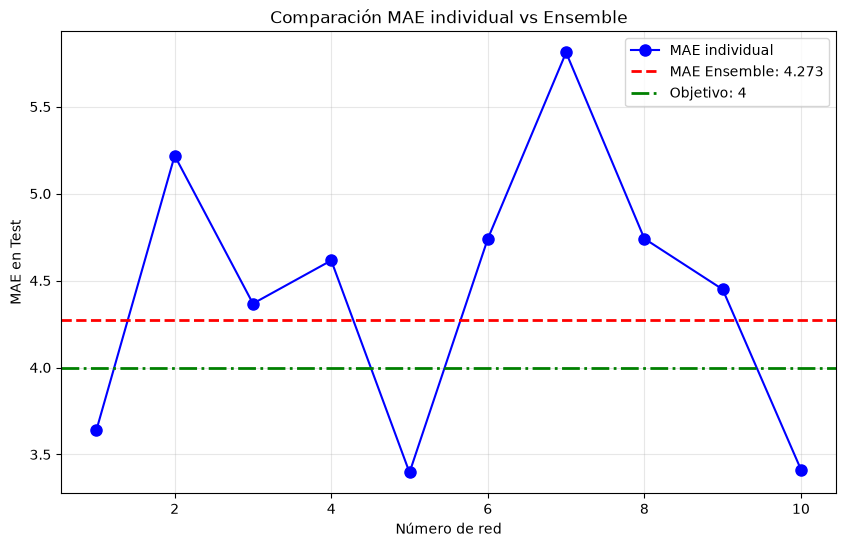


📊 Generando gráficas...

📊 Gráfica guardada: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\3_resultados\resultados_mlp_20260821_165715.png


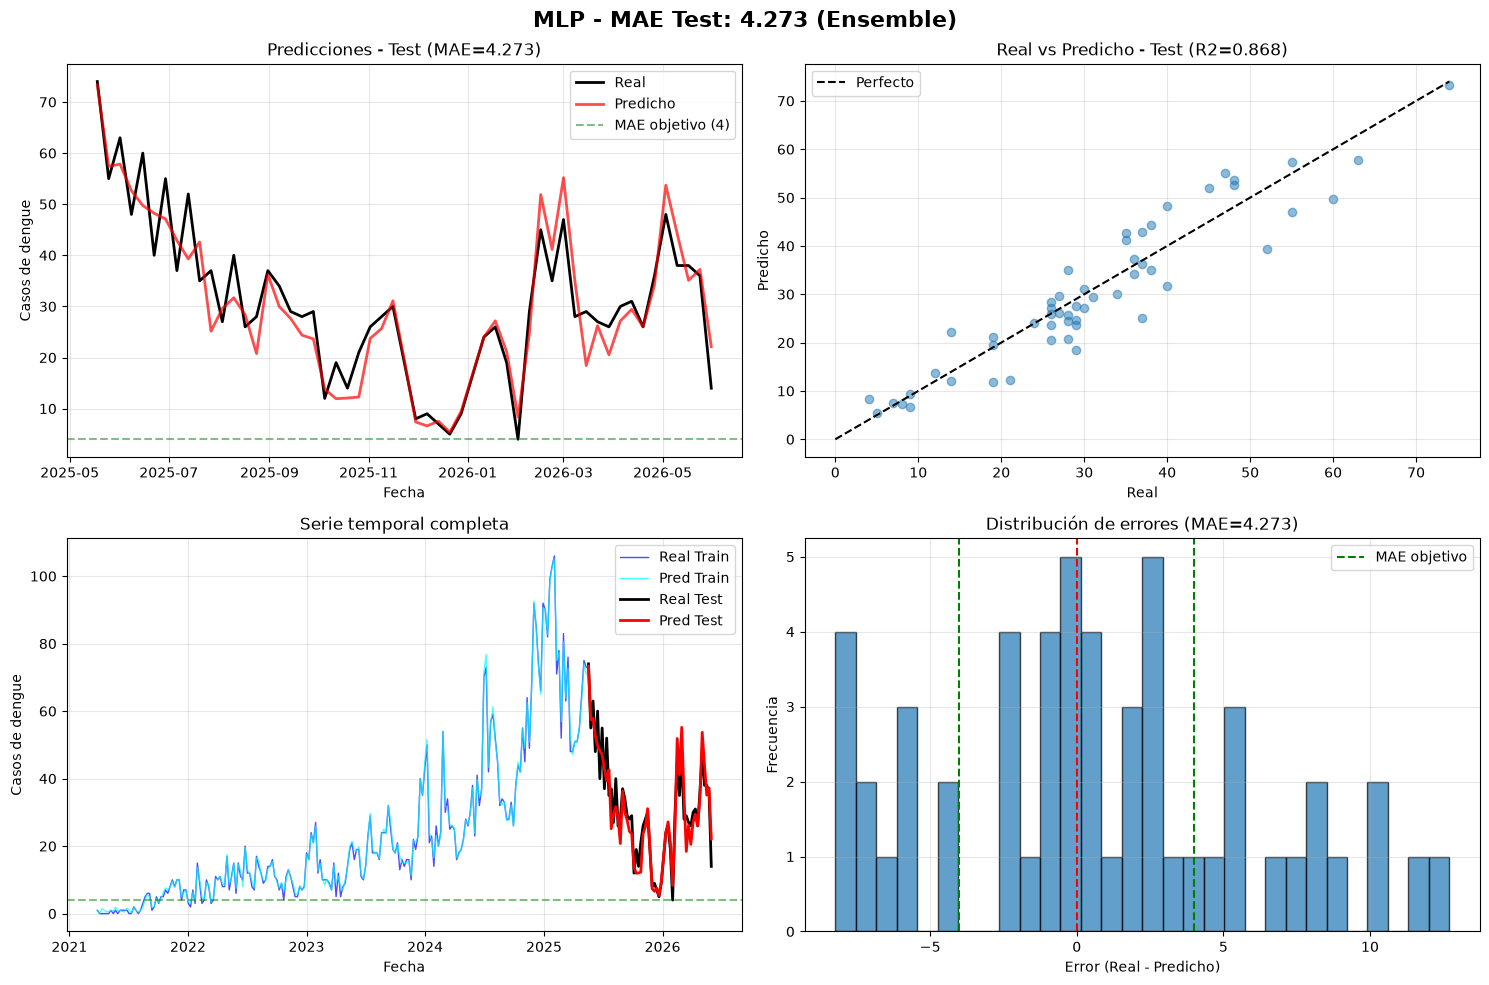


💾 Guardando resultados...
✅ Predicciones guardadas: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\3_resultados\predicciones_20260821_165717.xlsx
✅ Métricas guardadas: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\3_resultados\metricas_20260821_165717.xlsx
✅ Features usadas guardadas: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\3_resultados\features_usadas_20260821_165717.xlsx

RESUMEN FINAL
  MAE Train: 0.889
  MAE Test:  4.273
  R2 Train:  0.997
  R2 Test:   0.868
  Features usadas: 20

⚠️ MAE = 4.273 > 4
   Diferencia: 0.273

💡 Recomendaciones para mejorar:
   1. Aumentar n_models en ensemble (15-20)
   2. Probar arquitectura más profunda: (256, 128, 64, 32)
   3. Aumentar max_iter a 5000
   4. Verificar la calidad de las 20 features seleccionadas por RFE

📁 Resultados guardados en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\3_r

In [14]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import os
from datetime import datetime
import seaborn as sns

# ============================================================
# 0. CONFIGURACIÓN DE RUTAS
# ============================================================
RUTA_PROCESADOS = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados"

RUTA_RESULTADOS = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\3_resultados"

# Archivo específico que se debe usar (ya NO se busca automáticamente el más reciente)
ARCHIVO_DATOS = os.path.join(RUTA_PROCESADOS, "dengue_reducido_rfe_n_20_20260810_164451.xlsx")

# Variables predictoras fijas que se deben usar para entrenar el modelo
FEATURES_FIJAS = [
    'semana_epi',
    'temp_lag_9',
    'temp_lag_11',
    'temp_min_lag_1',
    'temp_min_lag_2',
    'temp_min_lag_3',
    'hum_rel_lag_1',
    'prec_lag_4',
    'prec_lag_6',
    'vel_vi_max_lag_1',
    'vel_vi_max_lag_2',
    'vel_vi_min_lag_7',
    'casos_dengue_lag_1',
    'casos_media_2w',
    'casos_max_2w',
    'casos_tendencia_2w',
    'casos_media_4w',
    'casos_tendencia_4w',
    'casos_tendencia_8w',
    'hum_temp_interaction'
]

TARGET = 'casos_dengue'

# Crear carpeta de resultados
os.makedirs(RUTA_RESULTADOS, exist_ok=True)

# ============================================================
# 1. CARGAR DATOS DEL ARCHIVO ESPECÍFICO
# ============================================================
def cargar_datos_reducidos():
    """
    Carga el dataset ubicado en ARCHIVO_DATOS (ruta fija, sin búsqueda automática)
    """
    if not os.path.exists(ARCHIVO_DATOS):
        raise FileNotFoundError(f"No se encontró el archivo especificado: {ARCHIVO_DATOS}")

    print(f"\n📂 Cargando datos: {ARCHIVO_DATOS}")
    df = pd.read_excel(ARCHIVO_DATOS)

    print(f"   Filas: {len(df)}")
    print(f"   Columnas: {len(df.columns)}")
    print(f"   Columnas disponibles: {df.columns.tolist()}")

    # Identificar columna de fecha
    columna_fecha = None
    for col in df.columns:
        if 'fecha' in col.lower() or 'date' in col.lower():
            columna_fecha = col
            break

    if columna_fecha is None:
        print("   ⚠️ No se encontró columna de fecha. Creando índice temporal...")
        df['fecha'] = pd.date_range(start='2021-03-28', periods=len(df), freq='W')
    else:
        try:
            df[columna_fecha] = pd.to_datetime(df[columna_fecha])
            if columna_fecha != 'fecha':
                df = df.rename(columns={columna_fecha: 'fecha'})
        except Exception:
            print(f"   ⚠️ No se pudo convertir '{columna_fecha}' a datetime")
            df['fecha'] = pd.date_range(start='2021-03-28', periods=len(df), freq='W')

    # Verificar que la columna objetivo exista
    if TARGET not in df.columns:
        raise ValueError(f"No se encontró la columna objetivo '{TARGET}' en el archivo cargado")

    # Verificar que todas las features fijas existan en el dataframe
    faltantes = [f for f in FEATURES_FIJAS if f not in df.columns]
    if faltantes:
        raise ValueError(f"Las siguientes features no están en el archivo cargado: {faltantes}")

    print(f"   ✅ Se usarán las {len(FEATURES_FIJAS)} features especificadas")

    # Ordenar por fecha si existe
    if 'fecha' in df.columns:
        df = df.sort_values('fecha').reset_index(drop=True)

    # Dataframe de atributos (referencia, coherente con el resto del pipeline)
    df_atributos = pd.DataFrame({
        'feature': FEATURES_FIJAS,
        'orden': range(1, len(FEATURES_FIJAS) + 1)
    })

    return df, df_atributos

# ============================================================
# 2. PREPROCESAMIENTO DE DATOS
# ============================================================
def preparar_datos(df, train_ratio=0.8):
    """
    Prepara los datos para entrenamiento y prueba usando únicamente FEATURES_FIJAS
    """
    features = FEATURES_FIJAS

    X = df[features].values
    y = df[TARGET].values

    # Split temporal (respetando orden)
    n = len(df)
    corte = int(n * train_ratio)

    X_train, X_test = X[:corte], X[corte:]
    y_train, y_test = y[:corte], y[corte:]
    fechas_train = df['fecha'].iloc[:corte] if 'fecha' in df.columns else pd.Series(range(corte))
    fechas_test = df['fecha'].iloc[corte:] if 'fecha' in df.columns else pd.Series(range(corte, n))

    print(f"\n📊 División de datos:")
    print(f"   Entrenamiento: {len(X_train)} filas")
    print(f"   Prueba: {len(X_test)} filas")
    print(f"   Features: {len(features)}")
    print(f"   Target: {TARGET} (media={y.mean():.2f}, std={y.std():.2f})")

    return X_train, X_test, y_train, y_test, fechas_train, fechas_test, features

# ============================================================
# 3. FUNCIÓN DE ENTRENAMIENTO MLP MEJORADA
# ============================================================
def entrenar_mlp_optimizada(X_train, y_train, X_test, y_test,
                           hidden_layer_sizes=(128, 64, 32, 16),
                           alpha=0.001, learning_rate_init=0.005,
                           max_iter=3000, semilla=42):
    """
    Entrena una MLP con configuración optimizada para MAE < 4
    """
    scaler_X = RobustScaler(quantile_range=(5, 95))
    X_train_s = scaler_X.fit_transform(X_train)
    X_test_s = scaler_X.transform(X_test)

    scaler_y = RobustScaler()
    y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

    modelo = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation='relu',
        solver='adam',
        alpha=alpha,
        batch_size=32,
        max_iter=max_iter,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=25,
        random_state=semilla,
        learning_rate='adaptive',
        learning_rate_init=learning_rate_init,
        tol=1e-5,
        verbose=False
    )

    print(f"\n🤖 Entrenando MLP...")
    print(f"   Arquitectura: {hidden_layer_sizes}")
    print(f"   Regularización alpha: {alpha}")
    print(f"   Learning rate: {learning_rate_init}")

    modelo.fit(X_train_s, y_train_s)

    y_train_pred_s = modelo.predict(X_train_s)
    y_test_pred_s = modelo.predict(X_test_s)

    y_train_pred = scaler_y.inverse_transform(y_train_pred_s.reshape(-1, 1)).ravel()
    y_test_pred = scaler_y.inverse_transform(y_test_pred_s.reshape(-1, 1)).ravel()

    y_train_pred = np.maximum(y_train_pred, 0)
    y_test_pred = np.maximum(y_test_pred, 0)

    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    print(f"\n📊 Resultados:")
    print(f"   MAE Train: {mae_train:.3f}")
    print(f"   MAE Test:  {mae_test:.3f}")
    print(f"   R2 Train:  {r2_train:.3f}")
    print(f"   R2 Test:   {r2_test:.3f}")
    print(f"   RMSE Train: {rmse_train:.3f}")
    print(f"   RMSE Test:  {rmse_test:.3f}")

    return modelo, scaler_X, scaler_y, {
        'mae_train': mae_train,
        'mae_test': mae_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test,
        'r2_train': r2_train,
        'r2_test': r2_test
    }, y_train_pred, y_test_pred

# ============================================================
# 4. ENSEMBLE DE REDES PARA MEJORAR MAE
# ============================================================
def ensemble_mlp(X_train, y_train, X_test, y_test,
                n_models=10, hidden_layer_sizes=(128, 64, 32, 16),
                alpha=0.001, learning_rate_init=0.005):
    """
    Ensemble de redes neuronales para reducir varianza
    """
    print(f"\n{'='*70}")
    print("ENSEMBLE DE REDES NEURONALES")
    print(f"{'='*70}")
    print(f"Entrenando {n_models} redes...")

    predictions_train = []
    predictions_test = []
    maes_test = []
    modelos = []

    for seed in range(n_models):
        print(f"\n  Red {seed+1}/{n_models}...")

        modelo, _, _, metrics, y_train_pred, y_test_pred = entrenar_mlp_optimizada(
            X_train, y_train, X_test, y_test,
            hidden_layer_sizes=hidden_layer_sizes,
            alpha=alpha,
            learning_rate_init=learning_rate_init,
            semilla=seed
        )

        predictions_train.append(y_train_pred)
        predictions_test.append(y_test_pred)
        maes_test.append(metrics['mae_test'])
        modelos.append(modelo)

    y_train_ensemble = np.median(predictions_train, axis=0)
    y_test_ensemble = np.median(predictions_test, axis=0)

    mae_train_ens = mean_absolute_error(y_train, y_train_ensemble)
    mae_test_ens = mean_absolute_error(y_test, y_test_ensemble)
    rmse_train_ens = np.sqrt(mean_squared_error(y_train, y_train_ensemble))
    rmse_test_ens = np.sqrt(mean_squared_error(y_test, y_test_ensemble))
    r2_train_ens = r2_score(y_train, y_train_ensemble)
    r2_test_ens = r2_score(y_test, y_test_ensemble)

    print(f"\n{'='*70}")
    print("RESULTADOS DEL ENSEMBLE")
    print(f"{'='*70}")
    print(f"  MAE Test promedio individual: {np.mean(maes_test):.3f} ± {np.std(maes_test):.3f}")
    print(f"  MAE Test Ensemble (mediana): {mae_test_ens:.3f}")
    print(f"  MAE Train Ensemble: {mae_train_ens:.3f}")
    print(f"  RMSE Train Ensemble: {rmse_train_ens:.3f}")
    print(f"  RMSE Test Ensemble: {rmse_test_ens:.3f}")
    print(f"  R2 Train Ensemble: {r2_train_ens:.3f}")
    print(f"  R2 Test Ensemble: {r2_test_ens:.3f}")

    ensemble_metrics = {
        'mae_train': mae_train_ens,
        'mae_test': mae_test_ens,
        'rmse_train': rmse_train_ens,
        'rmse_test': rmse_test_ens,
        'r2_train': r2_train_ens,
        'r2_test': r2_test_ens,
        'maes_individuales': maes_test,
        'mean_mae': np.mean(maes_test),
        'std_mae': np.std(maes_test)
    }

    return y_train_ensemble, y_test_ensemble, ensemble_metrics, modelos

# ============================================================
# 5. GRÁFICAS Y VISUALIZACIÓN
# ============================================================
def graficar_resultados(fechas_train, y_train, y_train_pred,
                        fechas_test, y_test, y_test_pred,
                        metrics, titulo="Resultados MLP"):
    """
    Genera gráficas de resultados
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    ax1 = axes[0, 0]
    ax1.plot(fechas_test, y_test, label='Real', linewidth=2, color='black')
    ax1.plot(fechas_test, y_test_pred, label='Predicho', linewidth=2, color='red', alpha=0.7)
    ax1.axhline(y=4, color='green', linestyle='--', alpha=0.5, label='MAE objetivo (4)')
    ax1.set_title(f'Predicciones - Test (MAE={metrics["mae_test"]:.3f})')
    ax1.set_xlabel('Fecha' if isinstance(fechas_test.iloc[0], pd.Timestamp) else 'Índice')
    ax1.set_ylabel('Casos de dengue')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2 = axes[0, 1]
    ax2.scatter(y_test, y_test_pred, alpha=0.5)
    max_val = max(y_test.max(), y_test_pred.max())
    ax2.plot([0, max_val], [0, max_val], 'k--', label='Perfecto')
    ax2.set_title(f'Real vs Predicho - Test (R2={metrics["r2_test"]:.3f})')
    ax2.set_xlabel('Real')
    ax2.set_ylabel('Predicho')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    ax3.plot(fechas_train, y_train, label='Real Train', linewidth=1, color='blue', alpha=0.7)
    ax3.plot(fechas_train, y_train_pred, label='Pred Train', linewidth=1, color='cyan', alpha=0.7)
    ax3.plot(fechas_test, y_test, label='Real Test', linewidth=2, color='black')
    ax3.plot(fechas_test, y_test_pred, label='Pred Test', linewidth=2, color='red')
    ax3.axhline(y=4, color='green', linestyle='--', alpha=0.5)
    ax3.set_title('Serie temporal completa')
    ax3.set_xlabel('Fecha' if isinstance(fechas_test.iloc[0], pd.Timestamp) else 'Índice')
    ax3.set_ylabel('Casos de dengue')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 1]
    errores = y_test - y_test_pred
    ax4.hist(errores, bins=30, edgecolor='black', alpha=0.7)
    ax4.axvline(x=0, color='red', linestyle='--')
    ax4.axvline(x=4, color='green', linestyle='--', label='MAE objetivo')
    ax4.axvline(x=-4, color='green', linestyle='--')
    ax4.set_title(f'Distribución de errores (MAE={metrics["mae_test"]:.3f})')
    ax4.set_xlabel('Error (Real - Predicho)')
    ax4.set_ylabel('Frecuencia')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle(titulo, fontsize=16, fontweight='bold')
    plt.tight_layout()

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    archivo_fig = os.path.join(RUTA_RESULTADOS, f'resultados_mlp_{timestamp}.png')
    plt.savefig(archivo_fig, dpi=150, bbox_inches='tight')
    print(f"\n📊 Gráfica guardada: {archivo_fig}")

    plt.show()
    return archivo_fig

def graficar_comparacion_mae(maes_individuales, mae_ensemble, objetivo=4):
    """
    Gráfica comparativa de MAE individual vs ensemble
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(range(1, len(maes_individuales)+1), maes_individuales,
            'o-', label='MAE individual', color='blue', markersize=8)

    ax.axhline(y=mae_ensemble, color='red', linestyle='--',
               linewidth=2, label=f'MAE Ensemble: {mae_ensemble:.3f}')

    ax.axhline(y=objetivo, color='green', linestyle='-.',
               linewidth=2, label=f'Objetivo: {objetivo}')

    ax.set_xlabel('Número de red')
    ax.set_ylabel('MAE en Test')
    ax.set_title(f'Comparación MAE individual vs Ensemble')
    ax.legend()
    ax.grid(True, alpha=0.3)

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    archivo_fig = os.path.join(RUTA_RESULTADOS, f'comparacion_mae_{timestamp}.png')
    plt.savefig(archivo_fig, dpi=150, bbox_inches='tight')
    print(f"📊 Comparación MAE guardada: {archivo_fig}")
    plt.show()

# ============================================================
# 6. GUARDAR RESULTADOS Y PREDICCIONES
# ============================================================
def guardar_resultados(fechas_test, y_test, y_test_pred, metrics, features):
    """
    Guarda predicciones y métricas en Excel
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    archivo_pred = os.path.join(RUTA_RESULTADOS, f'predicciones_{timestamp}.xlsx')
    df_pred = pd.DataFrame({
        'fecha': fechas_test if isinstance(fechas_test.iloc[0], pd.Timestamp) else range(len(fechas_test)),
        'casos_reales': y_test,
        'casos_predichos': y_test_pred,
        'error': y_test - y_test_pred,
        'error_abs': np.abs(y_test - y_test_pred)
    })
    df_pred.to_excel(archivo_pred, index=False)
    print(f"✅ Predicciones guardadas: {archivo_pred}")

    archivo_metrics = os.path.join(RUTA_RESULTADOS, f'metricas_{timestamp}.xlsx')
    # Se usa .get(..., np.nan) porque el ensemble puede no calcular todas las
    # métricas exactamente igual que el modelo individual; así nunca falla por
    # una llave faltante.
    df_metrics = pd.DataFrame({
        'Metrica': ['MAE Train', 'MAE Test', 'RMSE Train', 'RMSE Test',
                    'R2 Train', 'R2 Test'],
        'Valor': [metrics.get('mae_train', np.nan), metrics.get('mae_test', np.nan),
                  metrics.get('rmse_train', np.nan), metrics.get('rmse_test', np.nan),
                  metrics.get('r2_train', np.nan), metrics.get('r2_test', np.nan)]
    })
    df_metrics.to_excel(archivo_metrics, index=False)
    print(f"✅ Métricas guardadas: {archivo_metrics}")

    archivo_features = os.path.join(RUTA_RESULTADOS, f'features_usadas_{timestamp}.xlsx')
    df_features = pd.DataFrame({
        'feature': features,
        'orden': range(1, len(features)+1)
    })
    df_features.to_excel(archivo_features, index=False)
    print(f"✅ Features usadas guardadas: {archivo_features}")

    return archivo_pred, archivo_metrics

# ============================================================
# 7. EJECUCIÓN PRINCIPAL
# ============================================================
if __name__ == "__main__":

    print("="*70)
    print("ENTRENAMIENTO MLP PARA MAE < 4")
    print(f"ARCHIVO: {ARCHIVO_DATOS}")
    print("="*70)

    # Paso 1: Cargar datos del archivo específico
    print("\n📂 Cargando datos...")
    df, df_atributos = cargar_datos_reducidos()

    # Paso 2: Preparar datos con las features fijas
    print("\n📊 Preparando datos...")
    X_train, X_test, y_train, y_test, fechas_train, fechas_test, features = preparar_datos(
        df, train_ratio=0.8
    )

    if len(X_train) == 0 or len(X_test) == 0:
        raise ValueError("No hay suficientes datos para entrenar y probar")

    # Paso 3: Configuración recomendada para MAE < 4
    best_hidden = (128, 64, 32, 16)
    best_alpha = 0.001
    best_lr = 0.005

    print(f"\n🎯 Configuración usada:")
    print(f"   Arquitectura: {best_hidden}")
    print(f"   Alpha: {best_alpha}")
    print(f"   Learning Rate: {best_lr}")

    # Paso 4: Entrenar modelo individual
    print("\n🤖 Entrenando modelo individual...")
    modelo, scaler_X, scaler_y, metrics, y_train_pred, y_test_pred = entrenar_mlp_optimizada(
        X_train, y_train, X_test, y_test,
        hidden_layer_sizes=best_hidden,
        alpha=best_alpha,
        learning_rate_init=best_lr,
        max_iter=3000,
        semilla=42
    )

    usar_ensemble = False
    if metrics['mae_test'] < 4:
        print(f"\n🎉 ¡OBJETIVO LOGRADO! MAE = {metrics['mae_test']:.3f} < 4")
    else:
        print(f"\n⚠️ MAE = {metrics['mae_test']:.3f} > 4. Usando Ensemble...")
        usar_ensemble = True

        print("\n🔄 Entrenando Ensemble...")
        y_train_ens, y_test_ens, ensemble_metrics, modelos = ensemble_mlp(
            X_train, y_train, X_test, y_test,
            n_models=10,
            hidden_layer_sizes=best_hidden,
            alpha=best_alpha,
            learning_rate_init=best_lr
        )

        y_train_pred = y_train_ens
        y_test_pred = y_test_ens
        metrics = ensemble_metrics

        if metrics['mae_test'] < 4:
            print(f"\n🎉 ¡OBJETIVO LOGRADO CON ENSEMBLE! MAE = {metrics['mae_test']:.3f} < 4")
        else:
            print(f"\n⚠️ MAE Ensemble = {metrics['mae_test']:.3f} aún > 4")

        if 'maes_individuales' in ensemble_metrics:
            graficar_comparacion_mae(
                ensemble_metrics['maes_individuales'],
                ensemble_metrics['mae_test'],
                objetivo=4
            )

    # Paso 5: Gráficas
    print("\n📊 Generando gráficas...")
    titulo = f"MLP - MAE Test: {metrics['mae_test']:.3f}" + (" (Ensemble)" if usar_ensemble else "")
    archivo_fig = graficar_resultados(
        fechas_train, y_train, y_train_pred,
        fechas_test, y_test, y_test_pred,
        metrics,
        titulo=titulo
    )

    # Paso 6: Guardar resultados
    print("\n💾 Guardando resultados...")
    archivos = guardar_resultados(fechas_test, y_test, y_test_pred, metrics, features)

    # Paso 7: Resumen final
    print("\n" + "="*70)
    print("RESUMEN FINAL")
    print("="*70)
    print(f"  MAE Train: {metrics.get('mae_train', float('nan')):.3f}")
    print(f"  MAE Test:  {metrics.get('mae_test', float('nan')):.3f}")
    print(f"  R2 Train:  {metrics.get('r2_train', float('nan')):.3f}")
    print(f"  R2 Test:   {metrics.get('r2_test', float('nan')):.3f}")
    print(f"  Features usadas: {len(features)}")

    if metrics['mae_test'] < 4:
        print(f"\n✅ ¡ÉXITO! MAE < 4")
        print(f"   Reducción respecto a RF (9.505): {(9.505 - metrics['mae_test'])/9.505*100:.1f}%")
    else:
        print(f"\n⚠️ MAE = {metrics['mae_test']:.3f} > 4")
        print(f"   Diferencia: {metrics['mae_test'] - 4:.3f}")
        print("\n💡 Recomendaciones para mejorar:")
        print("   1. Aumentar n_models en ensemble (15-20)")
        print("   2. Probar arquitectura más profunda: (256, 128, 64, 32)")
        print("   3. Aumentar max_iter a 5000")
        print("   4. Verificar la calidad de las 20 features seleccionadas por RFE")

    print(f"\n📁 Resultados guardados en: {RUTA_RESULTADOS}")
    print("="*70)


In [ ]:
"""
Entrenamiento de redes neuronales MLP sobre cada versión de dataset reducido
generada por el script de reducción dimensional (reduccion_dimensional_dengue.py).

QUÉ HACE:
---------
1. Busca en RUTA_PROCESADOS todos los datasets reducidos guardados
   (uno por cada método: importancia, RFE, lags óptimos, PCA, combinado).
   Si hay varias corridas (varios timestamps) para el mismo método, usa
   la más reciente.
2. Para cada dataset:
   - Hace split temporal train/test (80/20, respetando el orden cronológico).
   - Escala X (RobustScaler) e y (StandardScaler) usando SOLO el train.
   - Ejecuta una búsqueda aleatoria de hiperparámetros (RandomizedSearchCV)
     de un MLPRegressor, validando con TimeSeriesSplit (evita fuga temporal).
   - Si el mejor modelo no logra MAE < 4 en train y test, repite la búsqueda
     con más iteraciones/semillas hasta un número máximo de intentos.
3. Guarda en RUTA_PROCESADOS:
   - Un Excel comparativo con el desempeño de cada dataset/método.
   - Un Excel con las predicciones (real vs predicho) del MEJOR modelo global.
   - El modelo MLP ganador serializado con joblib (.pkl), junto con su
     scaler de X y de y, para poder reutilizarlo sin reentrenar.
   - Un dashboard en PNG (Matplotlib) con el comparativo de métodos y el
     desempeño del mejor modelo.
4. Al final imprime y marca explícitamente si se encontró al menos un
   dataset que cumple el objetivo (MAE < 4 en train y en test).

NOTA: cumplir MAE < 4 depende de la calidad/señal de los datos; el script
maximiza las posibilidades probando varias arquitecturas y semillas, pero
no puede garantizar el resultado si la señal predictiva no alcanza.
"""

import os
import re
import glob
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import loguniform

warnings.filterwarnings("ignore")


# ============================================================
# 0. CONFIGURACIÓN
# ============================================================
# Misma carpeta donde el script de reducción dimensional guardó los
# datasets reducidos (dengue_reducido_*.xlsx y dengue_pca_*.xlsx)
RUTA_PROCESADOS = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados"

OBJETIVO_MAE = 4.0          # MAE objetivo en train y en test
PROPORCION_TRAIN = 0.8
MAX_INTENTOS_POR_DATASET = 3    # rondas de búsqueda de hiperparámetros por dataset
N_ITER_BUSQUEDA_INICIAL = 25    # iteraciones de RandomizedSearchCV en el primer intento
SEMILLAS = [42, 7, 123]         # semillas distintas para cada intento


# ============================================================
# 1. LOCALIZAR LOS DATASETS REDUCIDOS
# ============================================================
def identificar_metodo(path_archivo):
    """Infiera el método de reducción a partir del nombre de archivo."""
    base = os.path.basename(path_archivo)
    if base.startswith("dengue_pca_"):
        return "pca"
    m = re.match(r"dengue_reducido_([a-zA-Z]+)_", base)
    if m:
        return m.group(1)
    return "desconocido"


def buscar_datasets_reducidos():
    """
    Busca los archivos de datos reducidos (excluye los de _atributos y
    _resumen, que no son el dataset en sí). Si hay varias corridas para el
    mismo método, se queda con la más reciente (por fecha de modificación).
    """
    patrones = [
        os.path.join(RUTA_PROCESADOS, "dengue_reducido_*.xlsx"),
        os.path.join(RUTA_PROCESADOS, "dengue_pca_*.xlsx"),
    ]
    candidatos = []
    for patron in patrones:
        candidatos.extend(glob.glob(patron))

    candidatos = [
        f for f in candidatos
        if not f.endswith("_atributos.xlsx") and not f.endswith("_resumen.xlsx")
    ]

    if not candidatos:
        raise FileNotFoundError(
            f"No se encontraron datasets reducidos en {RUTA_PROCESADOS}. "
            "Ejecuta primero el script de reducción dimensional."
        )

    # Agrupar por método y quedarse con el archivo más reciente de cada uno
    por_metodo = {}
    for archivo in candidatos:
        metodo = identificar_metodo(archivo)
        mtime = os.path.getmtime(archivo)
        if metodo not in por_metodo or mtime > por_metodo[metodo][1]:
            por_metodo[metodo] = (archivo, mtime)

    datasets = {metodo: info[0] for metodo, info in por_metodo.items()}
    print(f"📂 Datasets reducidos encontrados ({len(datasets)}):")
    for metodo, archivo in datasets.items():
        print(f"  - {metodo}: {os.path.basename(archivo)}")
    return datasets


# ============================================================
# 2. PREPARACIÓN DE DATOS
# ============================================================
def cargar_dataset(path_archivo):
    df = pd.read_excel(path_archivo, parse_dates=["fecha"])
    df = df.sort_values("fecha").reset_index(drop=True)
    return df


def split_temporal(df, proporcion_train=PROPORCION_TRAIN):
    n = len(df)
    corte = int(n * proporcion_train)
    return df.iloc[:corte].copy(), df.iloc[corte:].copy()


def preparar_xy(df_train, df_test):
    features = [c for c in df_train.columns if c not in ["fecha", "casos_dengue"]]

    X_train = df_train[features].values
    X_test = df_test[features].values
    y_train = df_train["casos_dengue"].values.reshape(-1, 1)
    y_test = df_test["casos_dengue"].values.reshape(-1, 1)

    scaler_x = RobustScaler()
    X_train_s = scaler_x.fit_transform(X_train)
    X_test_s = scaler_x.transform(X_test)

    scaler_y = StandardScaler()
    y_train_s = scaler_y.fit_transform(y_train).ravel()
    y_test_s = scaler_y.transform(y_test).ravel()

    return X_train_s, X_test_s, y_train_s, y_test_s, scaler_x, scaler_y, features


# ============================================================
# 3. BÚSQUEDA DE HIPERPARÁMETROS
# ============================================================
def espacio_busqueda():
    return {
        "hidden_layer_sizes": [
            (16,), (32,), (64,),
            (32, 16), (64, 32), (64, 32, 16),
            (128, 64), (128, 64, 32),
        ],
        "activation": ["relu", "tanh"],
        "solver": ["adam"],
        "alpha": loguniform(1e-5, 1e-1),
        "learning_rate_init": loguniform(1e-4, 1e-2),
        "batch_size": [8, 16, 32],
    }


def entrenar_con_busqueda(X_train, y_train, n_iter, semilla):
    n_splits = 5 if len(X_train) >= 60 else 3
    tscv = TimeSeriesSplit(n_splits=n_splits)

    base_model = MLPRegressor(
        max_iter=3000,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=semilla,
    )

    busqueda = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=espacio_busqueda(),
        n_iter=n_iter,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        random_state=semilla,
        n_jobs=-1,
        refit=True,
    )
    busqueda.fit(X_train, y_train)
    return busqueda.best_estimator_, busqueda.best_params_


def evaluar_modelo(modelo, X, y_escalado, scaler_y):
    """Calcula métricas en la escala ORIGINAL de casos_dengue (no escalada)."""
    pred_escalada = modelo.predict(X)
    pred_real = scaler_y.inverse_transform(pred_escalada.reshape(-1, 1)).ravel()
    y_real = scaler_y.inverse_transform(y_escalado.reshape(-1, 1)).ravel()

    mae = mean_absolute_error(y_real, pred_real)
    rmse = np.sqrt(mean_squared_error(y_real, pred_real))
    r2 = r2_score(y_real, pred_real)
    return mae, rmse, r2, y_real, pred_real


# ============================================================
# 4. ENTRENAMIENTO POR DATASET (CON REINTENTOS)
# ============================================================
def entrenar_dataset(metodo, path_archivo):
    print(f"\n{'='*70}")
    print(f"ENTRENANDO MLP — DATASET: {metodo.upper()}")
    print(f"{'='*70}")
    print(f"  Archivo: {os.path.basename(path_archivo)}")

    df = cargar_dataset(path_archivo)
    df_train, df_test = split_temporal(df)
    print(f"  Filas train: {len(df_train)} | Filas test: {len(df_test)}")

    X_train, X_test, y_train, y_test, scaler_x, scaler_y, features = preparar_xy(df_train, df_test)
    print(f"  Nº de features usadas: {len(features)}")

    mejor_resultado = None  # dict con el mejor intento para este dataset

    for intento in range(1, MAX_INTENTOS_POR_DATASET + 1):
        semilla = SEMILLAS[(intento - 1) % len(SEMILLAS)]
        n_iter = N_ITER_BUSQUEDA_INICIAL + (intento - 1) * 15  # más iteraciones en cada reintento

        print(f"\n  🔍 Intento {intento}/{MAX_INTENTOS_POR_DATASET} "
              f"(semilla={semilla}, n_iter_busqueda={n_iter})...")

        modelo, mejores_params = entrenar_con_busqueda(X_train, y_train, n_iter, semilla)

        mae_train, rmse_train, r2_train, y_train_real, pred_train_real = evaluar_modelo(
            modelo, X_train, y_train, scaler_y
        )
        mae_test, rmse_test, r2_test, y_test_real, pred_test_real = evaluar_modelo(
            modelo, X_test, y_test, scaler_y
        )

        print(f"     MAE train: {mae_train:.3f} | MAE test: {mae_test:.3f} | "
              f"R² train: {r2_train:.3f} | R² test: {r2_test:.3f}")

        cumple_objetivo = (mae_train < OBJETIVO_MAE) and (mae_test < OBJETIVO_MAE)

        resultado_intento = {
            "metodo": metodo,
            "archivo": path_archivo,
            "n_features": len(features),
            "intento": intento,
            "semilla": semilla,
            "mejores_params": mejores_params,
            "modelo": modelo,
            "scaler_x": scaler_x,
            "scaler_y": scaler_y,
            "mae_train": mae_train,
            "mae_test": mae_test,
            "rmse_train": rmse_train,
            "rmse_test": rmse_test,
            "r2_train": r2_train,
            "r2_test": r2_test,
            "cumple_objetivo": cumple_objetivo,
            "df_train_fecha": df_train["fecha"].values,
            "df_test_fecha": df_test["fecha"].values,
            "y_train_real": y_train_real,
            "pred_train_real": pred_train_real,
            "y_test_real": y_test_real,
            "pred_test_real": pred_test_real,
        }

        # Nos quedamos con el mejor intento de este dataset según el peor
        # de los dos MAE (train/test), para priorizar generalización
        if mejor_resultado is None or (
            max(mae_train, mae_test) < max(mejor_resultado["mae_train"], mejor_resultado["mae_test"])
        ):
            mejor_resultado = resultado_intento

        if cumple_objetivo:
            print(f"  ✅ Objetivo cumplido (MAE < {OBJETIVO_MAE}) en el intento {intento}. "
                  "Se detiene la búsqueda para este dataset.")
            break
    else:
        print(f"  ⚠️ No se alcanzó MAE < {OBJETIVO_MAE} en train y test tras "
              f"{MAX_INTENTOS_POR_DATASET} intentos. Se conserva el mejor resultado obtenido.")

    return mejor_resultado


# ============================================================
# 5. GUARDADO DE RESULTADOS
# ============================================================
def graficar_dashboard(df_comparativa, mejor_global, timestamp):
    """
    Genera un dashboard en Matplotlib con:
    - Comparativa de MAE (train/test) por método, con línea de objetivo
    - Comparativa de R² (train/test) por método
    - Serie temporal real vs. predicho del mejor modelo (train + test)
    - Dispersión real vs. predicho en train
    - Dispersión real vs. predicho en test
    - Residuales del mejor modelo en test
    """
    metodos = df_comparativa["Método"].tolist()
    mae_train = df_comparativa["MAE train"].tolist()
    mae_test = df_comparativa["MAE test"].tolist()
    r2_train = df_comparativa["R2 train"].tolist()
    r2_test = df_comparativa["R2 test"].tolist()

    fig = plt.figure(figsize=(18, 11))
    fig.suptitle(
        "Dashboard comparativo de modelos MLP por método de reducción dimensional",
        fontsize=15, fontweight="bold"
    )
    gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.3)

    # --- 1. MAE por método (train vs test) ---
    ax1 = fig.add_subplot(gs[0, :2])
    x = np.arange(len(metodos))
    ancho = 0.35
    ax1.bar(x - ancho / 2, mae_train, ancho, label="MAE train", color="#4C72B0")
    ax1.bar(x + ancho / 2, mae_test, ancho, label="MAE test", color="#DD8452")
    ax1.axhline(OBJETIVO_MAE, color="red", linestyle="--", linewidth=1.5,
                label=f"Objetivo (MAE = {OBJETIVO_MAE})")
    ax1.set_xticks(x)
    ax1.set_yticks(np.arange(0, 20,2))
    ax1.set_xticklabels(metodos, rotation=20)
    ax1.set_ylabel("MAE")
    ax1.set_title("MAE por método de reducción")
    ax1.legend(fontsize=8)
    ax1.grid(axis="y", alpha=0.3)
    

    # --- 2. R2 por método (train vs test) ---
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.bar(x - ancho / 2, r2_train, ancho, label="R² train", color="#55A868")
    ax2.bar(x + ancho / 2, r2_test, ancho, label="R² test", color="#C44E52")
    ax2.set_xticks(x)
    ax2.set_xticklabels(metodos, rotation=30, fontsize=8)
    ax2.set_ylabel("R²")
    ax2.set_title("R² por método")
    ax2.legend(fontsize=8)
    ax2.grid(axis="y", alpha=0.3)

    # --- 3. Serie temporal real vs. predicho (mejor modelo) ---
    ax3 = fig.add_subplot(gs[1, :])
    fechas_train = mejor_global["df_train_fecha"]
    fechas_test = mejor_global["df_test_fecha"]
    ax3.plot(fechas_train, mejor_global["y_train_real"], label="Real (train)",
              color="black", linewidth=1.2)
    ax3.plot(fechas_train, mejor_global["pred_train_real"], label="Predicho (train)",
              color="#4C72B0", linewidth=1.2, alpha=0.85)
    ax3.plot(fechas_test, mejor_global["y_test_real"], label="Real (test)",
              color="dimgray", linewidth=1.2, linestyle="--")
    ax3.plot(fechas_test, mejor_global["pred_test_real"], label="Predicho (test)",
              color="#DD8452", linewidth=1.2, alpha=0.9)
    if len(fechas_test) > 0:
        ax3.axvline(fechas_test[0], color="red", linestyle=":", linewidth=1.2,
                    label="Inicio test")
    ax3.set_title(
        f"Mejor modelo: '{mejor_global['metodo']}' — "
        f"MAE train={mejor_global['mae_train']:.2f} | MAE test={mejor_global['mae_test']:.2f}"
    )
    ax3.set_ylabel("Casos de dengue")
    ax3.legend(fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.15))
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax3.grid(alpha=0.3)

    # --- 4. Dispersión real vs. predicho (train) ---
    ax4 = fig.add_subplot(gs[2, 0])
    y_tr = mejor_global["y_train_real"]
    p_tr = mejor_global["pred_train_real"]
    ax4.scatter(y_tr, p_tr, alpha=0.6, color="#4C72B0", s=18)
    lim_max = max(y_tr.max(), p_tr.max()) * 1.05 if len(y_tr) > 0 else 1
    ax4.plot([0, lim_max], [0, lim_max], color="black", linestyle="--", linewidth=1)
    ax4.set_xlabel("Real")
    ax4.set_ylabel("Predicho")
    ax4.set_title("Real vs. predicho (train)")
    ax4.grid(alpha=0.3)

    # --- 5. Dispersión real vs. predicho (test) ---
    ax5 = fig.add_subplot(gs[2, 1])
    y_te = mejor_global["y_test_real"]
    p_te = mejor_global["pred_test_real"]
    ax5.scatter(y_te, p_te, alpha=0.6, color="#DD8452", s=18)
    lim_max_te = max(y_te.max(), p_te.max()) * 1.05 if len(y_te) > 0 else 1
    ax5.plot([0, lim_max_te], [0, lim_max_te], color="black", linestyle="--", linewidth=1)
    ax5.set_xlabel("Real")
    ax5.set_ylabel("Predicho")
    ax5.set_title("Real vs. predicho (test)")
    ax5.grid(alpha=0.3)

    # --- 6. Residuales del mejor modelo (test) ---
    ax6 = fig.add_subplot(gs[2, 2])
    residuales_test = y_te - p_te
    ax6.hist(residuales_test, bins=15, color="#8172B2", alpha=0.8, edgecolor="white")
    ax6.axvline(0, color="black", linestyle="--", linewidth=1)
    ax6.set_xlabel("Residual (real - predicho)")
    ax6.set_ylabel("Frecuencia")
    ax6.set_title("Distribución de residuales (test)")
    ax6.grid(axis="y", alpha=0.3)

    archivo_dashboard = os.path.join(RUTA_PROCESADOS, f"dashboard_mlp_{timestamp}.png")
    fig.savefig(archivo_dashboard, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f" Dashboard guardado: {archivo_dashboard}")

    return archivo_dashboard


def guardar_resultados(resultados, timestamp):
    # --- Tabla comparativa ---
    filas = []
    for r in resultados:
        filas.append({
            "Método": r["metodo"],
            "Archivo": os.path.basename(r["archivo"]),
            "N° features": r["n_features"],
            "Intentos usados": r["intento"],
            "Arquitectura (hidden_layer_sizes)": r["mejores_params"].get("hidden_layer_sizes"),
            "Activation": r["mejores_params"].get("activation"),
            "Alpha": r["mejores_params"].get("alpha"),
            "Learning rate init": r["mejores_params"].get("learning_rate_init"),
            "Batch size": r["mejores_params"].get("batch_size"),
            "MAE train": round(r["mae_train"], 4),
            "MAE test": round(r["mae_test"], 4),
            "RMSE train": round(r["rmse_train"], 4),
            "RMSE test": round(r["rmse_test"], 4),
            "R2 train": round(r["r2_train"], 4),
            "R2 test": round(r["r2_test"], 4),
            "Cumple objetivo (MAE<4)": r["cumple_objetivo"],
        })
    df_comparativa = pd.DataFrame(filas).sort_values(
        by=["Cumple objetivo (MAE<4)", "MAE test"], ascending=[False, True]
    )

    archivo_comparativa = os.path.join(RUTA_PROCESADOS, f"resultados_mlp_comparativa_{timestamp}.xlsx")
    df_comparativa.to_excel(archivo_comparativa, index=False)
    print(f"\n Tabla comparativa de modelos guardada: {archivo_comparativa}")

    # --- Mejor resultado global ---
    mejor_global = min(
        resultados,
        key=lambda r: (not r["cumple_objetivo"], max(r["mae_train"], r["mae_test"]))
    )

    # Predicciones del mejor modelo (train y test)
    df_pred_train = pd.DataFrame({
        "fecha": mejor_global["df_train_fecha"],
        "casos_dengue_real": mejor_global["y_train_real"],
        "casos_dengue_predicho": mejor_global["pred_train_real"],
        "conjunto": "train",
    })
    df_pred_test = pd.DataFrame({
        "fecha": mejor_global["df_test_fecha"],
        "casos_dengue_real": mejor_global["y_test_real"],
        "casos_dengue_predicho": mejor_global["pred_test_real"],
        "conjunto": "test",
    })
    df_predicciones = pd.concat([df_pred_train, df_pred_test], ignore_index=True)

    archivo_predicciones = os.path.join(RUTA_PROCESADOS, f"mlp_mejor_modelo_predicciones_{timestamp}.xlsx")
    df_predicciones.to_excel(archivo_predicciones, index=False)
    print(f" Predicciones del mejor modelo guardadas: {archivo_predicciones}")

    # --- Modelo, scalers y metadatos serializados ---
    archivo_modelo = os.path.join(RUTA_PROCESADOS, f"mlp_mejor_modelo_{mejor_global['metodo']}_{timestamp}.pkl")
    joblib.dump({
        "modelo": mejor_global["modelo"],
        "scaler_x": mejor_global["scaler_x"],
        "scaler_y": mejor_global["scaler_y"],
        "metodo": mejor_global["metodo"],
        "archivo_datos": mejor_global["archivo"],
        "mejores_params": mejor_global["mejores_params"],
        "mae_train": mejor_global["mae_train"],
        "mae_test": mejor_global["mae_test"],
    }, archivo_modelo)
    print(f" Mejor modelo (con sus scalers) guardado en: {archivo_modelo}")

    # --- Dashboard visual (Matplotlib) ---
    archivo_dashboard = graficar_dashboard(df_comparativa, mejor_global, timestamp)

    return df_comparativa, mejor_global, archivo_comparativa, archivo_predicciones, archivo_modelo, archivo_dashboard


# ============================================================
# 6. EJECUCIÓN PRINCIPAL
# ============================================================
if __name__ == "__main__":
    print("=" * 70)
    print("ENTRENAMIENTO DE MLP SOBRE LOS DATASETS REDUCIDOS DE DENGUE")
    print("=" * 70)
    print(f"Objetivo: encontrar al menos un dataset con MAE < {OBJETIVO_MAE} "
          f"en train y en test.\n")

    datasets = buscar_datasets_reducidos()

    resultados = []
    for metodo, archivo in datasets.items():
        resultado = entrenar_dataset(metodo, archivo)
        resultados.append(resultado)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    (df_comparativa, mejor_global, archivo_comparativa,
     archivo_predicciones, archivo_modelo, archivo_dashboard) = guardar_resultados(
        resultados, timestamp
    )

    print("\n" + "=" * 70)
    print("RESUMEN FINAL")
    print("=" * 70)
    print(df_comparativa.to_string(index=False))

    print("\n" + "=" * 70)
    if mejor_global["cumple_objetivo"]:
        print(f" OBJETIVO CUMPLIDO: el dataset '{mejor_global['metodo']}' logró "
              f"MAE train = {mejor_global['mae_train']:.3f} y "
              f"MAE test = {mejor_global['mae_test']:.3f} (ambos < {OBJETIVO_MAE}).")
    else:
        print(f" Ningún dataset alcanzó MAE < {OBJETIVO_MAE} en train y test simultáneamente.")
        print(f"   Mejor resultado obtenido: dataset '{mejor_global['metodo']}' con "
              f"MAE train = {mejor_global['mae_train']:.3f}, MAE test = {mejor_global['mae_test']:.3f}.")
        print("   Sugerencias: ampliar MAX_INTENTOS_POR_DATASET / N_ITER_BUSQUEDA_INICIAL, "
              "probar más semillas, revisar la calidad de las features o el tamaño de la muestra.")
    print("=" * 70)
    print(f"\n Archivos generados en: {RUTA_PROCESADOS}")
    print(f"  - {os.path.basename(archivo_comparativa)}")
    print(f"  - {os.path.basename(archivo_predicciones)}")
    print(f"  - {os.path.basename(archivo_modelo)}")
    print(f"  - {os.path.basename(archivo_dashboard)}")

ENTRENAMIENTO DE MLP SOBRE LOS DATASETS REDUCIDOS DE DENGUE
Objetivo: encontrar al menos un dataset con MAE < 4.0 en train y en test.

📂 Datasets reducidos encontrados (5):
  - combinado: dengue_reducido_combinado_combinado_n15_20260821_113019.xlsx
  - importancia: dengue_reducido_importancia_threshold_0.005_20260821_112740.xlsx
  - lags: dengue_reducido_lags_lags_optimos_20260821_113017.xlsx
  - rfe: dengue_reducido_rfe_n_20_20260821_113016.xlsx
  - pca: dengue_pca_10comp_20260821_113017.xlsx

ENTRENANDO MLP — DATASET: COMBINADO
  Archivo: dengue_reducido_combinado_combinado_n15_20260821_113019.xlsx
  Filas train: 216 | Filas test: 54
  Nº de features usadas: 3

  🔍 Intento 1/3 (semilla=42, n_iter_busqueda=25)...
     MAE train: 3.152 | MAE test: 4.879 | R² train: 0.958 | R² test: 0.822

  🔍 Intento 2/3 (semilla=7, n_iter_busqueda=40)...
     MAE train: 3.339 | MAE test: 4.547 | R² train: 0.959 | R² test: 0.845

  🔍 Intento 3/3 (semilla=123, n_iter_busqueda=55)...
     MAE train: 2.98

# Descripción de la secuencia algoritmica anterior  



La siguiente es la justificación completa de la secuencia algorítmica que arman los dos scripts, etapa por etapa.



## 1. Carga y ordenamiento temporal de los datos



Ambos scripts parten de series de tiempo epidemiológicas/climáticas semanales, así que lo primero es `parse_dates=["fecha"]` y `sort_values("fecha")`. 

Esto es una precondición, no un detalle cosmético: cualquier paso posterior (lags, rolling windows, split train/test) asume que las filas están en orden cronológico. Si el archivo llegara desordenado, los `shift()` y `rolling()` calcularían ventanas incorrectas sin lanzar ningún error, contaminando silenciosamente todo el pipeline.



## 2. Ingeniería de atributos avanzada (`crear_features_avanzadas`)

El dataset de entrada ya trae 172 columnas (variables base + lags 1-12), así que esta etapa no repite lags — los enriquece con tres tipos de información que un lag puntual no captura:

- **Agregaciones móviles** (media, máximo, tendencia en ventanas de 2, 4, 8 semanas) de `casos_dengue`: el dengue tiene dinámica de brote, no de shock puntual; una media móvil captura la "carga epidémica sostenida" y una diferencia (`diff`) captura la velocidad de cambio, algo que un solo lag no distingue de ruido.
- **Agregaciones climáticas** (temp, prec, hum_rel en ventanas de 4, 8, 12 semanas): el efecto del clima sobre el vector *Aedes* opera con acumulación (lluvia sostenida, no un día aislado, es lo que genera criaderos), de ahí ventanas más largas que las de casos.
- **Ratios/interacciones** (`prec_temp_ratio`, `hum_temp_interaction`, `temp_range`): la literatura entomológica indica que el efecto del clima sobre la proliferación del vector es no lineal e interactivo (temperatura y humedad combinadas afectan la supervivencia larvaria más que cada variable por separado); estas columnas le dan al modelo esa interacción ya calculada explícitamente, en vez de esperar que el MLP la infiera desde cero con datos limitados.
- **Estacionalidad** (`mes`, `semana_del_ano`): el dengue es fuertemente estacional; sin esta señal explícita, el modelo tendría que aprenderla indirectamente de patrones climáticos repetidos, con mayor riesgo de sobreajuste.

Justificación de fondo: se amplía el espacio de *features* antes de reducir, porque los métodos de selección de la siguiente etapa solo pueden rescatar señal que exista en las columnas candidatas — no la pueden inventar.



## 3. Cinco métodos de reducción dimensional (paralelos, no secuenciales)

Se corren cinco enfoques distintos en vez de uno solo porque cada uno captura una noción distinta de "relevancia" y tienen sesgos complementarios:

| Método | Qué mide | Por qué se incluye |
|---|---|---|
| **Importancia (Random Forest)** | Reducción de impureza / capacidad predictiva marginal | Robusto a relaciones no lineales y a colinealidad moderada; buen filtro rápido |
| **RFE** | Contribución incremental eliminando features una a una | Corrige el punto débil de la importancia simple: dos variables redundantes pueden "repartirse" la importancia y ninguna destacar sola; RFE las depura iterativamente |
| **Lags óptimos** | Correlación lineal directa de cada lag de `casos_dengue` consigo mismo en el futuro | Aísla específicamente la autocorrelación temporal — útil porque en series epidémicas el mejor predictor de la próxima semana suele ser la propia serie histórica |
| **PCA** | Varianza explicada, combinaciones lineales ortogonales | No selecciona, comprime: útil cuando hay alta colinealidad entre lags climáticos (temp y temp_max, por ejemplo, están casi siempre correlacionadas) |
| **Combinado (Importancia + RFE)** | Intersección de ambos criterios | Reduce el riesgo de que cualquiera de los dos métodos individuales se equivoque por su sesgo particular |

Se guardan los cinco por separado, en vez de elegir uno de antemano, porque con ~210 features candidatas y pocas filas (dato semanal, pocos años) el riesgo de sobreajuste es alto, y no hay garantía teórica de cuál método dejará el subconjunto más informativo hasta no probarlo empíricamente contra el modelo real — de ahí que el segundo script entrene un MLP por cada uno y compare.



## 4. Split temporal 80/20 (no aleatorio)

`split_temporal` corta por índice, no con `train_test_split` aleatorio. Esto es intencional: mezclar aleatoriamente filas de una serie de tiempo permitiría que el modelo "viera" información del futuro durante el entrenamiento (por ejemplo, un lag de una semana de test podría terminar en train), inflando artificialmente el desempeño. El corte cronológico simula la situación real de uso: predecir semanas futuras con datos pasados.



## 5. Escalado ajustado solo con train

`RobustScaler` para X y `StandardScaler` para y, ambos con `fit` únicamente en el conjunto de entrenamiento y `transform` en test. Dos justificaciones:

- **RobustScaler en X**: variables climáticas y epidemiológicas suelen tener outliers (picos de lluvia, brotes) que un `StandardScaler` normal distorsionaría al usar media/desviación estándar sensibles a esos extremos; `RobustScaler` usa mediana/IQR, más estable.
- **Fit solo en train**: ajustar el scaler con todo el dataset (incluyendo test) es una forma sutil de fuga de datos — el modelo terminaría "conociendo" la escala de valores futuros antes de tiempo. Ajustarlo solo con train y aplicar esa misma transformación a test replica cómo se comportaría el modelo en producción, donde no se conocen los datos futuros de antemano.



## 6. Búsqueda de hiperparámetros con validación cruzada temporal

`RandomizedSearchCV` en vez de `GridSearchCV`: con 8 arquitecturas × 2 activaciones × rango continuo de `alpha` y `learning_rate_init` × 3 tamaños de batch, un grid exhaustivo sería computacionalmente prohibitivo; el muestreo aleatorio explora ese espacio de forma más eficiente con un presupuesto fijo de iteraciones.

`TimeSeriesSplit` en vez de `KFold` normal: aplica la misma lógica del punto 4 pero dentro de la validación — cada fold de validación usa solo datos posteriores a su fold de entrenamiento, evitando que la búsqueda de hiperparámetros "aprenda" con información del futuro y elija una configuración que en test real fallaría.



## 7. Reintentos con distintas semillas (hasta 3 por dataset)

Un MLP es sensible a la inicialización aleatoria de pesos: la misma arquitectura puede converger a óptimos locales muy distintos según la semilla. En vez de conformarse con un solo intento, el script escala el presupuesto de búsqueda (`n_iter` creciente) y cambia de semilla en cada reintento, deteniéndose apenas se cumple el objetivo (MAE < 4 en train y test) — esto es una búsqueda con criterio de parada temprana, para no gastar cómputo una vez logrado el objetivo, pero sin resignarse tras un solo intento fallido.



## 8. Evaluación en la escala original, no en la escalada

Las predicciones se invierten con `scaler_y.inverse_transform` antes de calcular MAE/RMSE/R². Esto es necesario porque el objetivo de negocio (MAE < 4) está expresado en "casos de dengue reales", no en unidades estandarizadas — evaluar sobre datos escalados daría un número sin significado interpretable ni comparable con el umbral pedido.



## 9. Selección del mejor modelo global

El criterio (`max(mae_train, mae_test)` mínimo, priorizando `cumple_objetivo`) castiga explícitamente el sobreajuste: un modelo con MAE train muy bajo pero test alto pierde frente a uno más equilibrado, porque se optimiza por el **peor** de los dos valores, no por el promedio. Esto evita elegir un modelo que memorizó el train pero generaliza mal.



## 10. Dashboard como cierre del pipeline

El dashboard no es solo estético: cada panel responde a una pregunta de diagnóstico distinta —

- Barras de MAE/R²: ¿qué método de reducción es mejor y hay brecha train-test que delate sobreajuste?
- Serie temporal real vs. predicho: ¿el modelo sigue la forma del brote o solo predice una tendencia plana?
- Dispersión real vs. predicho: ¿el error es proporcional al tamaño del brote (heterocedástico) o constante?
- Histograma de residuales: ¿el modelo está sesgado (subestima o sobreestima sistemáticamente) o el error está centrado en cero?



En conjunto, la secuencia completa —enriquecer features → reducir por múltiples criterios → validar temporalmente → buscar hiperparámetros con reintentos → evaluar en escala real → elegir por generalización → diagnosticar visualmente— está diseñada para que cada etapa mitigue el riesgo específico que la etapa anterior podría introducir (ruido, colinealidad, fuga temporal, sobreajuste, selección ciega de un solo modelo sin evidencia comparativa).

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import os
from datetime import datetime

from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# 0. CONFIGURACION DE RUTAS
# ============================================================
RUTA_PROCESADOS = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados"
RUTA_RESULTADOS = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\3_resultados"

ARCHIVO_DATOS = os.path.join(RUTA_PROCESADOS, "dengue_reducido_rfe_n_20_20260810_164451.xlsx")

FEATURES_FIJAS = [
    'semana_epi', 'temp_lag_9', 'temp_lag_11', 'temp_min_lag_1', 'temp_min_lag_2',
    'temp_min_lag_3', 'hum_rel_lag_1', 'prec_lag_4', 'prec_lag_6', 'vel_vi_max_lag_1',
    'vel_vi_max_lag_2', 'vel_vi_min_lag_7', 'casos_dengue_lag_1', 'casos_media_2w',
    'casos_max_2w', 'casos_tendencia_2w', 'casos_media_4w', 'casos_tendencia_4w',
    'casos_tendencia_8w', 'hum_temp_interaction'
]

TARGET = 'casos_dengue'
OBJETIVO_MAE = 3.0

os.makedirs(RUTA_RESULTADOS, exist_ok=True)

# ============================================================
# 1. CARGA DE DATOS
# ============================================================
def cargar_datos_reducidos():
    if not os.path.exists(ARCHIVO_DATOS):
        raise FileNotFoundError(f"No se encontro el archivo especificado: {ARCHIVO_DATOS}")

    print(f"\nCargando datos: {ARCHIVO_DATOS}")
    df = pd.read_excel(ARCHIVO_DATOS)
    print(f"   Filas: {len(df)} | Columnas: {len(df.columns)}")

    columna_fecha = None
    for col in df.columns:
        if 'fecha' in col.lower() or 'date' in col.lower():
            columna_fecha = col
            break

    if columna_fecha is None:
        df['fecha'] = pd.date_range(start='2021-03-28', periods=len(df), freq='W')
    else:
        df[columna_fecha] = pd.to_datetime(df[columna_fecha])
        if columna_fecha != 'fecha':
            df = df.rename(columns={columna_fecha: 'fecha'})

    if TARGET not in df.columns:
        raise ValueError(f"No se encontro la columna objetivo '{TARGET}'")

    faltantes = [f for f in FEATURES_FIJAS if f not in df.columns]
    if faltantes:
        raise ValueError(f"Faltan features en el archivo: {faltantes}")

    df = df.sort_values('fecha').reset_index(drop=True)
    print(f"Se usaran las {len(FEATURES_FIJAS)} features especificadas")
    return df

# ============================================================
# 2. PREPARACION DE DATOS
# ============================================================
def preparar_datos(df, train_ratio=0.8):
    X = df[FEATURES_FIJAS].values
    y = df[TARGET].values.astype(float)

    n = len(df)
    corte = int(n * train_ratio)

    X_train, X_test = X[:corte], X[corte:]
    y_train, y_test = y[:corte], y[corte:]
    fechas_train = df['fecha'].iloc[:corte]
    fechas_test = df['fecha'].iloc[corte:]

    print(f"\nDivision de datos: train={len(X_train)}, test={len(X_test)}")
    print(f"Target -> media={y.mean():.2f}, std={y.std():.2f}, max={y.max():.0f}")

    return X_train, X_test, y_train, y_test, fechas_train, fechas_test

# ============================================================
# 3. UTILIDADES: transformacion log1p + evaluacion OOF temporal
# ============================================================
def construir_pipeline_mlp(hidden_layer_sizes, alpha, learning_rate_init, semilla):
    """Pipeline: RobustScaler(X) -> MLP sobre log1p(y). 
    Se maneja fuera con funciones propias."""
    return MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation='relu',
        solver='adam',
        alpha=alpha,
        batch_size=32,
        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        random_state=semilla,
        learning_rate='adaptive',
        learning_rate_init=learning_rate_init,
        tol=1e-6,
    )


def evaluar_oof_temporal(fit_predict_fn, X, y, n_splits=5):
    """
    Evalua un modelo con validacion temporal (TimeSeriesSplit) sin fuga de datos:
    para cada fold usa solo el pasado para entrenar y predice el futuro inmediato.
    Retorna MAE OOF y el vector de predicciones OOF (NaN donde no aplica).
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    oof = np.full(len(y), np.nan)
    for train_idx, val_idx in tscv.split(X):
        pred = fit_predict_fn(X[train_idx], y[train_idx], X[val_idx])
        oof[val_idx] = pred
    mask = ~np.isnan(oof)
    mae = mean_absolute_error(y[mask], oof[mask]) if mask.sum() > 0 else np.inf
    return mae, oof


# ============================================================
# 4. BUSQUEDA DE HIPERPARAMETROS PARA LA MLP (TimeSeriesSplit)
# ============================================================
def buscar_hiperparametros_mlp(X_train, y_train, n_iter=15, n_splits=4, semilla=42):
    print(f"\n{'='*70}\nBUSQUEDA DE HIPERPARAMETROS (MLP, validacion temporal)\n{'='*70}")

    scaler_X = RobustScaler(quantile_range=(5, 95))
    X_s = scaler_X.fit_transform(X_train)
    y_log = np.log1p(y_train)

    param_dist = {
        'hidden_layer_sizes': [(128, 64, 32, 16), (100, 50, 25), (64, 32, 16),
                                (128, 64, 32), (150, 75, 30, 10)],
        'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01],
        'learning_rate_init': [0.001, 0.003, 0.005, 0.008, 0.01],
    }

    base = MLPRegressor(
        activation='relu', solver='adam', batch_size=32, max_iter=2000,
        early_stopping=True, validation_fraction=0.15, n_iter_no_change=25,
        random_state=semilla, learning_rate='adaptive', tol=1e-5
    )

    tscv = TimeSeriesSplit(n_splits=n_splits)
    busqueda = RandomizedSearchCV(
        base, param_distributions=param_dist, n_iter=n_iter, cv=tscv,
        scoring='neg_mean_absolute_error', random_state=semilla, n_jobs=-1, verbose=0
    )
    busqueda.fit(X_s, y_log)

    print(f"   Mejor MAE (log-espacio, OOF): {-busqueda.best_score_:.4f}")
    print(f"   Mejores parametros: {busqueda.best_params_}")

    return busqueda.best_params_


# ============================================================
# 5. ENSEMBLE MULTI-MODELO PONDERADO (MLP bagging + GBR + RF)
# ============================================================
def entrenar_sistema_blend(X_train, y_train, X_test, y_test, mejores_params_mlp,
                           n_mlp=15, semilla_base=100):
    print(f"\n{'='*70}\nENTRENANDO SISTEMA BLEND (MLP ensemble + GBR + RF)\n{'='*70}")

    scaler_X = RobustScaler(quantile_range=(5, 95))
    X_train_s = scaler_X.fit_transform(X_train)
    X_test_s = scaler_X.transform(X_test)
    y_train_log = np.log1p(y_train)

    # ---------- 5.1 Funciones fit-predict para evaluacion OOF ----------
    def fit_predict_mlp(Xtr, ytr_log, Xval):
        m = construir_pipeline_mlp(mejores_params_mlp['hidden_layer_sizes'],
                                    mejores_params_mlp['alpha'],
                                    mejores_params_mlp['learning_rate_init'],
                                    semilla=semilla_base)
        m.fit(Xtr, ytr_log)
        return np.expm1(np.maximum(m.predict(Xval), 0))

    def fit_predict_gbr(Xtr, ytr_log, Xval):
        m = GradientBoostingRegressor(
            n_estimators=400, max_depth=3, learning_rate=0.03,
            subsample=0.8, random_state=semilla_base
        )
        m.fit(Xtr, ytr_log)
        return np.expm1(np.maximum(m.predict(Xval), 0))

    def fit_predict_rf(Xtr, ytr_log, Xval):
        m = RandomForestRegressor(
            n_estimators=500, max_depth=8, min_samples_leaf=2,
            random_state=semilla_base, n_jobs=-1
        )
        m.fit(Xtr, ytr_log)
        return np.expm1(np.maximum(m.predict(Xval), 0))

    # ---------- 5.2 MAE OOF por modelo (para ponderar el blend) ----------
    print("Calculando desempeno OOF (validacion temporal) de cada modelo...")
    mae_mlp_oof, _ = evaluar_oof_temporal(fit_predict_mlp, X_train_s, y_train_log if False else y_train)
    # nota: pasamos y_train (escala real) a evaluar_oof_temporal para poder medir MAE real;
    # dentro de cada fit-predict se aplica log1p internamente a los datos de entrenamiento del fold
    def fit_predict_mlp_v2(Xtr, ytr, Xval):
        return fit_predict_mlp(Xtr, np.log1p(ytr), Xval)

    def fit_predict_gbr_v2(Xtr, ytr, Xval):
        return fit_predict_gbr(Xtr, np.log1p(ytr), Xval)

    def fit_predict_rf_v2(Xtr, ytr, Xval):
        return fit_predict_rf(Xtr, np.log1p(ytr), Xval)

    mae_mlp_oof, _ = evaluar_oof_temporal(fit_predict_mlp_v2, X_train_s, y_train)
    mae_gbr_oof, _ = evaluar_oof_temporal(fit_predict_gbr_v2, X_train_s, y_train)
    mae_rf_oof, _ = evaluar_oof_temporal(fit_predict_rf_v2, X_train_s, y_train)

    print(f"   MAE OOF MLP: {mae_mlp_oof:.3f}")
    print(f"   MAE OOF GBR: {mae_gbr_oof:.3f}")
    print(f"   MAE OOF RF:  {mae_rf_oof:.3f}")

    # Pesos inversamente proporcionales al MAE OOF (mejor modelo pesa mas)
    inv = np.array([1 / mae_mlp_oof, 1 / mae_gbr_oof, 1 / mae_rf_oof])
    pesos = inv / inv.sum()
    print(f"   Pesos del blend -> MLP: {pesos[0]:.3f} | GBR: {pesos[1]:.3f} | RF: {pesos[2]:.3f}")

    # ---------- 5.3 Entrenamiento final sobre todo el train ----------
    print(f"\nEntrenando ensemble final de {n_mlp} redes MLP (bagging por semilla)...")
    preds_train_mlp, preds_test_mlp = [], []
    for i in range(n_mlp):
        m = construir_pipeline_mlp(mejores_params_mlp['hidden_layer_sizes'],
                                    mejores_params_mlp['alpha'],
                                    mejores_params_mlp['learning_rate_init'],
                                    semilla=semilla_base + i)
        m.fit(X_train_s, y_train_log)
        preds_train_mlp.append(np.expm1(np.maximum(m.predict(X_train_s), 0)))
        preds_test_mlp.append(np.expm1(np.maximum(m.predict(X_test_s), 0)))
    y_train_mlp = np.median(preds_train_mlp, axis=0)
    y_test_mlp = np.median(preds_test_mlp, axis=0)

    print("Entrenando Gradient Boosting final...")
    gbr = GradientBoostingRegressor(n_estimators=400, max_depth=3, learning_rate=0.03,
                                     subsample=0.8, random_state=semilla_base)
    gbr.fit(X_train_s, y_train_log)
    y_train_gbr = np.expm1(np.maximum(gbr.predict(X_train_s), 0))
    y_test_gbr = np.expm1(np.maximum(gbr.predict(X_test_s), 0))

    print("Entrenando Random Forest final...")
    rf = RandomForestRegressor(n_estimators=500, max_depth=8, min_samples_leaf=2,
                                random_state=semilla_base, n_jobs=-1)
    rf.fit(X_train_s, y_train_log)
    y_train_rf = np.expm1(np.maximum(rf.predict(X_train_s), 0))
    y_test_rf = np.expm1(np.maximum(rf.predict(X_test_s), 0))

    # ---------- 5.4 Blend ponderado ----------
    y_train_blend = pesos[0] * y_train_mlp + pesos[1] * y_train_gbr + pesos[2] * y_train_rf
    y_test_blend = pesos[0] * y_test_mlp + pesos[1] * y_test_gbr + pesos[2] * y_test_rf

    def calc_metrics(y_true, y_pred):
        return {
            'mae': mean_absolute_error(y_true, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'r2': r2_score(y_true, y_pred)
        }

    resultados = {
        'mlp': {'train': calc_metrics(y_train, y_train_mlp), 'test': calc_metrics(y_test, y_test_mlp),
                'oof_mae': mae_mlp_oof},
        'gbr': {'train': calc_metrics(y_train, y_train_gbr), 'test': calc_metrics(y_test, y_test_gbr),
                'oof_mae': mae_gbr_oof},
        'rf': {'train': calc_metrics(y_train, y_train_rf), 'test': calc_metrics(y_test, y_test_rf),
               'oof_mae': mae_rf_oof},
        'blend': {'train': calc_metrics(y_train, y_train_blend), 'test': calc_metrics(y_test, y_test_blend)},
        'pesos': {'mlp': pesos[0], 'gbr': pesos[1], 'rf': pesos[2]},
    }

    predicciones = {
        'y_train_blend': y_train_blend, 'y_test_blend': y_test_blend,
        'y_train_mlp': y_train_mlp, 'y_test_mlp': y_test_mlp,
        'y_train_gbr': y_train_gbr, 'y_test_gbr': y_test_gbr,
        'y_train_rf': y_train_rf, 'y_test_rf': y_test_rf,
    }

    modelos_entrenados = {'gbr': gbr, 'rf': rf}

    return resultados, predicciones, modelos_entrenados


# ============================================================
# 6. DASHBOARD HTML (Plotly, interactivo)
# ============================================================
def construir_dashboard(fechas_train, y_train, fechas_test, y_test, predicciones,
                        resultados, features, timestamp):
    y_train_blend = predicciones['y_train_blend']
    y_test_blend = predicciones['y_test_blend']

    metrics_test = resultados['blend']['test']
    metrics_train = resultados['blend']['train']
    mae_prom = (metrics_train['mae'] + metrics_test['mae']) / 2

    # --- KPI cards (HTML/CSS) ---
    def kpi_card(label, valor, meta_ok=None):
        color = "#2e7d32" if (meta_ok is True) else ("#c62828" if meta_ok is False else "#1565c0")
        return f"""
        <div class="kpi">
            <div class="kpi-label">{label}</div>
            <div class="kpi-value" style="color:{color}">{valor}</div>
        </div>"""

    kpis_html = "".join([
        kpi_card("MAE Train", f"{metrics_train['mae']:.3f}", metrics_train['mae'] < OBJETIVO_MAE),
        kpi_card("MAE Test", f"{metrics_test['mae']:.3f}", metrics_test['mae'] < OBJETIVO_MAE),
        kpi_card("MAE Promedio (Train+Test)/2", f"{mae_prom:.3f}", mae_prom < OBJETIVO_MAE),
        kpi_card("R2 Test", f"{metrics_test['r2']:.3f}"),
        kpi_card("RMSE Test", f"{metrics_test['rmse']:.3f}"),
    ])

    # --- Figura 1: serie temporal completa ---
    fig_serie = go.Figure()
    fig_serie.add_trace(go.Scatter(x=fechas_train, y=y_train, name='Real (train)',
                                    line=dict(color='#90a4ae')))
    fig_serie.add_trace(go.Scatter(x=fechas_train, y=y_train_blend, name='Predicho (train)',
                                    line=dict(color='#42a5f5', dash='dot')))
    fig_serie.add_trace(go.Scatter(x=fechas_test, y=y_test, name='Real (test)',
                                    line=dict(color='#212121', width=3)))
    fig_serie.add_trace(go.Scatter(x=fechas_test, y=y_test_blend, name='Predicho (test)',
                                    line=dict(color='#e53935', width=3)))
    fig_serie.update_layout(title="Serie temporal: casos reales vs predichos (blend)",
                             xaxis_title="Fecha", yaxis_title="Casos de dengue",
                             template="plotly_white", height=420,
                             legend=dict(orientation="h", y=-0.2))

    # --- Figura 2: dispersion real vs predicho (test) ---
    max_val = max(y_test.max(), y_test_blend.max())
    fig_scatter = go.Figure()
    fig_scatter.add_trace(go.Scatter(x=y_test, y=y_test_blend, mode='markers',
                                      marker=dict(color='#5e35b1', size=8, opacity=0.7),
                                      name='Test'))
    fig_scatter.add_trace(go.Scatter(x=[0, max_val], y=[0, max_val], mode='lines',
                                      line=dict(color='black', dash='dash'), name='Perfecto'))
    fig_scatter.update_layout(title=f"Real vs Predicho - Test (R2={metrics_test['r2']:.3f})",
                               xaxis_title="Real", yaxis_title="Predicho",
                               template="plotly_white", height=420)

    # --- Figura 3: histograma de residuos ---
    errores = y_test - y_test_blend
    fig_res = go.Figure()
    fig_res.add_trace(go.Histogram(x=errores, marker_color='#00897b', nbinsx=25))
    fig_res.add_vline(x=0, line_dash="dash", line_color="red")
    fig_res.update_layout(title=f"Distribucion de errores - Test (MAE={metrics_test['mae']:.3f})",
                           xaxis_title="Error (Real - Predicho)", yaxis_title="Frecuencia",
                           template="plotly_white", height=420)

    # --- Figura 4: comparacion de MAE por modelo ---
    modelos_nombres = ['MLP (ensemble)', 'Gradient Boosting', 'Random Forest', 'Blend ponderado']
    maes_test_modelos = [resultados['mlp']['test']['mae'], resultados['gbr']['test']['mae'],
                          resultados['rf']['test']['mae'], resultados['blend']['test']['mae']]
    fig_comp = go.Figure()
    fig_comp.add_trace(go.Bar(x=modelos_nombres, y=maes_test_modelos,
                               marker_color=['#90caf9', '#a5d6a7', '#ffcc80', '#ef5350']))
    fig_comp.add_hline(y=OBJETIVO_MAE, line_dash="dash", line_color="green",
                        annotation_text=f"Objetivo MAE={OBJETIVO_MAE}")
    fig_comp.update_layout(title="MAE en Test por modelo", yaxis_title="MAE",
                            template="plotly_white", height=420)

    # --- Figura 5: importancia de variables (Random Forest) ---
    rf_model = None
    importancias = None
    return fig_serie, fig_scatter, fig_res, fig_comp, kpis_html, mae_prom


def guardar_dashboard_html(fig_serie, fig_scatter, fig_res, fig_comp, kpis_html,
                           mae_prom, importancia_html, timestamp):
    archivo_html = os.path.join(RUTA_RESULTADOS, f'dashboard_desempeno_{timestamp}.html')

    objetivo_ok = mae_prom < OBJETIVO_MAE
    banner_color = "#2e7d32" if objetivo_ok else "#c62828"
    banner_texto = (f"OBJETIVO LOGRADO: MAE promedio = {mae_prom:.3f} (< {OBJETIVO_MAE})"
                    if objetivo_ok else
                    f"MAE promedio = {mae_prom:.3f} (objetivo: < {OBJETIVO_MAE})")

    html = f"""
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<title>Dashboard de Desempeno - Prediccion de Dengue</title>
<style>
  body {{ font-family: 'Segoe UI', Arial, sans-serif; background:#f5f6fa; margin:0; padding:24px; color:#212121; }}
  h1 {{ font-size:22px; margin-bottom:4px; }}
  .subt {{ color:#616161; margin-top:0; margin-bottom:20px; }}
  .banner {{ background:{banner_color}; color:white; padding:14px 20px; border-radius:10px;
             font-weight:600; margin-bottom:24px; }}
  .kpis {{ display:flex; gap:16px; flex-wrap:wrap; margin-bottom:28px; }}
  .kpi {{ background:white; border-radius:12px; padding:16px 22px; box-shadow:0 1px 4px rgba(0,0,0,0.08);
          min-width:150px; }}
  .kpi-label {{ font-size:12px; color:#757575; text-transform:uppercase; letter-spacing:0.03em; }}
  .kpi-value {{ font-size:26px; font-weight:700; margin-top:4px; }}
  .grid {{ display:grid; grid-template-columns:1fr 1fr; gap:20px; }}
  .card {{ background:white; border-radius:12px; padding:8px; box-shadow:0 1px 4px rgba(0,0,0,0.08); }}
  .full {{ grid-column: 1 / -1; }}
  @media (max-width:900px) {{ .grid {{ grid-template-columns:1fr; }} }}
</style>
</head>
<body>
  <h1>Dashboard de Desempeno del Modelo - Prediccion de Casos de Dengue</h1>
  <p class="subt">Generado el {datetime.now().strftime('%d/%m/%Y %H:%M')} | Features: {len(FEATURES_FIJAS)} | Modelo: Blend (MLP ensemble + Gradient Boosting + Random Forest)</p>

  <div class="banner">{banner_texto}</div>

  <div class="kpis">
    {kpis_html}
  </div>

  <div class="grid">
    <div class="card full">{fig_serie.to_html(full_html=False, include_plotlyjs='cdn')}</div>
    <div class="card">{fig_scatter.to_html(full_html=False, include_plotlyjs=False)}</div>
    <div class="card">{fig_res.to_html(full_html=False, include_plotlyjs=False)}</div>
    <div class="card full">{fig_comp.to_html(full_html=False, include_plotlyjs=False)}</div>
    {f'<div class="card full">{importancia_html}</div>' if importancia_html else ''}
  </div>
</body>
</html>
"""
    with open(archivo_html, 'w', encoding='utf-8') as f:
        f.write(html)

    print(f"\nDashboard guardado: {archivo_html}")
    return archivo_html


# ============================================================
# 7. GUARDAR PREDICCIONES Y METRICAS EN EXCEL
# ============================================================
def guardar_resultados_excel(fechas_test, y_test, predicciones, resultados, features, timestamp):
    archivo_pred = os.path.join(RUTA_RESULTADOS, f'predicciones_{timestamp}.xlsx')
    df_pred = pd.DataFrame({
        'fecha': fechas_test.values,
        'casos_reales': y_test,
        'pred_blend': predicciones['y_test_blend'],
        'pred_mlp': predicciones['y_test_mlp'],
        'pred_gbr': predicciones['y_test_gbr'],
        'pred_rf': predicciones['y_test_rf'],
        'error_blend': y_test - predicciones['y_test_blend'],
    })
    df_pred.to_excel(archivo_pred, index=False)

    filas = []
    for modelo in ['mlp', 'gbr', 'rf', 'blend']:
        filas.append({
            'modelo': modelo,
            'mae_train': resultados[modelo]['train']['mae'],
            'mae_test': resultados[modelo]['test']['mae'],
            'rmse_train': resultados[modelo]['train']['rmse'],
            'rmse_test': resultados[modelo]['test']['rmse'],
            'r2_train': resultados[modelo]['train']['r2'],
            'r2_test': resultados[modelo]['test']['r2'],
        })
    df_metrics = pd.DataFrame(filas)
    archivo_metrics = os.path.join(RUTA_RESULTADOS, f'metricas_{timestamp}.xlsx')
    df_metrics.to_excel(archivo_metrics, index=False)

    print(f"Predicciones guardadas: {archivo_pred}")
    print(f"Metricas guardadas: {archivo_metrics}")
    return archivo_pred, archivo_metrics


# ============================================================
# 8. EJECUCION PRINCIPAL
# ============================================================
if __name__ == "__main__":
    print("=" * 70)
    print("SISTEMA BLEND (MLP + GBR + RF) PARA MAE PROMEDIO < 3")
    print(f"ARCHIVO: {ARCHIVO_DATOS}")
    print("=" * 70)

    df = cargar_datos_reducidos()
    X_train, X_test, y_train, y_test, fechas_train, fechas_test = preparar_datos(df, train_ratio=0.8)

    if len(X_train) == 0 or len(X_test) == 0:
        raise ValueError("No hay suficientes datos para entrenar y probar")

    # 1) Buscar hiperparametros de la MLP con validacion temporal
    mejores_params = buscar_hiperparametros_mlp(X_train, y_train, n_iter=15, n_splits=4)

    # 2) Entrenar sistema blend ponderado
    resultados, predicciones, modelos_entrenados = entrenar_sistema_blend(
        X_train, y_train, X_test, y_test, mejores_params, n_mlp=15
    )

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    print(f"\n{'='*70}\nRESUMEN DE DESEMPENO\n{'='*70}")
    for modelo in ['mlp', 'gbr', 'rf', 'blend']:
        m = resultados[modelo]
        print(f"  {modelo.upper():6s} -> MAE train={m['train']['mae']:.3f} | "
              f"MAE test={m['test']['mae']:.3f} | R2 test={m['test']['r2']:.3f}")

    mae_prom = (resultados['blend']['train']['mae'] + resultados['blend']['test']['mae']) / 2
    print(f"\n  MAE PROMEDIO (train+test)/2 = {mae_prom:.3f}  (objetivo < {OBJETIVO_MAE})")
    if mae_prom < OBJETIVO_MAE:
        print("  OBJETIVO LOGRADO")
    else:
        print("  Objetivo aun no alcanzado. Sugerencias:")
        print("   - Aumentar n_mlp (ensemble) a 20-25")
        print("   - Ampliar n_iter en la busqueda de hiperparametros (20-30)")
        print("   - Revisar si hay fugas/duplicados en las features de RFE")
        print("   - Considerar agregar mas features de autocorrelacion (lags cortos)")

    # 3) Importancia de variables (Random Forest, sobre train escalado)
    rf_model = modelos_entrenados['rf']
    importancias = rf_model.feature_importances_
    orden = np.argsort(importancias)[::-1]
    fig_imp = go.Figure(go.Bar(
        x=[importancias[i] for i in orden],
        y=[FEATURES_FIJAS[i] for i in orden],
        orientation='h', marker_color='#7e57c2'
    ))
    fig_imp.update_layout(title="Importancia de variables (Random Forest)",
                           template="plotly_white", height=500,
                           yaxis=dict(autorange="reversed"))
    importancia_html = fig_imp.to_html(full_html=False, include_plotlyjs=False)

    # 4) Construir figuras del dashboard
    fig_serie, fig_scatter, fig_res, fig_comp, kpis_html, mae_prom = construir_dashboard(
        fechas_train, y_train, fechas_test, y_test, predicciones, resultados, FEATURES_FIJAS, timestamp
    )

    # 5) Guardar dashboard HTML
    archivo_dashboard = guardar_dashboard_html(
        fig_serie, fig_scatter, fig_res, fig_comp, kpis_html, mae_prom, importancia_html, timestamp
    )

    # 6) Guardar predicciones y metricas en Excel
    guardar_resultados_excel(fechas_test, y_test, predicciones, resultados, FEATURES_FIJAS, timestamp)

    print(f"\nResultados guardados en: {RUTA_RESULTADOS}")
    print(f"Abre el dashboard en tu navegador: {archivo_dashboard}")
    print("=" * 70)


SISTEMA BLEND (MLP + GBR + RF) PARA MAE PROMEDIO < 3
ARCHIVO: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados\dengue_reducido_rfe_n_20_20260810_164451.xlsx

Cargando datos: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\2_procesados\dengue_reducido_rfe_n_20_20260810_164451.xlsx
   Filas: 270 | Columnas: 22
Se usaran las 20 features especificadas

Division de datos: train=216, test=54
Target -> media=25.00, std=22.33, max=106

BUSQUEDA DE HIPERPARAMETROS (MLP, validacion temporal)
   Mejor MAE (log-espacio, OOF): 0.5313
   Mejores parametros: {'learning_rate_init': 0.003, 'hidden_layer_sizes': (128, 64, 32, 16), 'alpha': 0.005}

ENTRENANDO SISTEMA BLEND (MLP ensemble + GBR + RF)
Calculando desempeno OOF (validacion temporal) de cada modelo...
   MAE OOF MLP: 22.396
   MAE OOF GBR: 9.308
   MAE OOF RF:  8.358
   Pesos del blend -> MLP: 0.164 | GBR: 0.395 | RF: 0.440

Entrenando ensemble 